<a href="https://colab.research.google.com/github/Kris01655/Mineria-de-Datos/blob/main/EV3_Sismologia1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROYECTO DE SISMOS EN CHILE - Exploración de datos, modelación predictiva y clustering

**INTEGRANTES:**  
- Francisca Otárola  
- Kristyn Hernandez  

En este notebook fuimos desarrollando el proyecto por etapas, siguiendo las tres evaluaciones.

En la primera evaluación trabajamos la exploración de los datos sísmicos de Chile, **revisando variables como magnitud, profundidad, latitud y longitud**. También **incorporamos información de comunas y regiones**, y aplicamos codificación de variables para poder construir matrices de correlación y visualizar mejor las relaciones entre los datos.

En la segunda evaluación pasamos a la parte predictiva. Para eso cruzamos los sismos de la Región Metropolitana con un dataset de viviendas, con el objetivo de analizar si la magnitud sísmica podía relacionarse con el precio promedio de las casas. En esta etapa aplicamos un modelo **Decision Tree Regressor**, calculamos métricas y visualizamos sus resultados.

En la tercera evaluación integramos las correcciones anteriores y agregamos nuevos elementos, como set de prueba, métricas más completas, modelo **K-Means**, un archivo final para dashboard y un bonus de **web scraping** con datos reales recientes desde la página de Sismología de Chile.

En resumen, este notebook muestra cómo fuimos avanzando desde una exploración inicial de los datos hasta una etapa más completa, incorporando análisis estadístico, predicción, clustering y testeo con datos externos.

## Importación de librerías

En esta primera parte importé las librerías base que iba a usar en casi todo el notebook. Aquí cargué pandas y numpy para trabajar los datos, y matplotlib con seaborn para hacer las visualizaciones.

In [ ]:
#EV1 CODIGO 1
import pandas as pd #usamos panda para la manipulacion y estructuracion de los datos en el dataframe.
import numpy as np #usamos numpy para hacer las operaciones matematicas y numericas.
import matplotlib.pyplot as plt #usamos matplotlib y seaborn para generar visualizaciones grafiscas.
import seaborn as sns

In [ ]:
#EV1 CODIGO 2
#carga de datos
df = pd.read_csv('sismos_data.csv')

In [ ]:
#EV1 CODIGO 3
#visualizamos las 5 primeras filas
df.head(5)

,Date(UTC),Latitude,Longitude,Depth,Magnitude
0,2025-05-26 03:50:27,-19.63,-69.49,97,5.6
1,2025-05-13 00:47:58,-51.25,-72.28,28,5.1
2,2025-05-05 09:46:48,-29.49,-71.84,48,5.0
3,2025-05-05 02:17:48,-31.89,-70.88,88,5.1
4,2025-05-02 15:23:49,-27.52,-72.48,30,5.8


In [ ]:
#EV1 CODIGO 4
#visualizamos las 5 ultimas filas
df.tail(5)

,Date(UTC),Latitude,Longitude,Depth,Magnitude
4013,2012-03-24 07:28:33,-33.05,-71.06,69,5.2
4014,2012-03-19 21:52:39,-25.00,-69.75,100,5.0
4015,2012-03-10 02:26:57,-19.74,-69.25,101,5.3
4016,2012-03-04 16:27:20,-21.60,-70.06,47,5.3
4017,2012-03-03 11:01:47,-30.19,-71.45,35,5.6


In [ ]:
#EV1 CODIGO 5
#ver cantidad de filas y columnas
df.shape

(4018, 5)

In [ ]:
#EV1 CODIGO 6
#ver tipos de datos de las columnas
df.dtypes

,0
Date(UTC),object
Latitude,float64
Longitude,float64
Depth,int64
Magnitude,float64


In [ ]:
#EV1 CODIGO 7
#aqui nos aseguramos de que el dataset contenga nulos
df.isnull().sum()

,0
Date(UTC),0
Latitude,0
Longitude,0
Depth,0
Magnitude,0


In [ ]:
#EV1 CODIGO 8
df.columns

Index(['Date(UTC)', 'Latitude', 'Longitude', 'Depth', 'Magnitude'], dtype='object')

Para lograr el analisis, importamos los datasets necesarios utilizando las librerias de pandas y geopandas y en esta parte tenemos tres fuentes de datos (sismos_data.csv), (regiones.geojson) y (comunas.geojson).

In [ ]:
#EV1 CODIGO 9
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#EV1 CODIGO 10
#aqui cargo los archivos
df = pd.read_csv('sismos_data.csv')#esto contiene el registro de los eventos sismicos
gdf_regiones = gpd.read_file('regiones.geojson')#estos archivos geoespaciales nos dejaran hacer
gdf_comunas = gpd.read_file('comunas.geojson')#la union geografica para asociar cada sismo en su ubicacion correspondiente.

Una vez que los datos se cargaron podemos transformar nuestro dataframe original en un geodataframe. Con este geodataframe podemos tomar las coordenadas geograficas (Latitud, Longitud) utilizando la referencia de coordenadas EPSG:4326.
Con esto permitiendonos realizar la ubicacion de los sismos.

In [ ]:
#EV1 CODIGO 11
#convertimos a geodataframe
gdf_sismos = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']),
    crs='EPSG:4326'
)

Tras integrar los datos realizamos un print para verificar si hay existencia de datos nulos, y el resultado fue un 0 lo que confirma la integridad del dataset, esto nos garantiza que contamos con una base de datos limpia y asi podemos seguir con nuestro analisis estadistico.


In [ ]:
#EV1 CODIGO 12
print("Nulos en el dataset original:", df.isnull().sum().sum())

Nulos en el dataset original: 0


Aqui realizamos la union espacial de nuestros sismos con los datos geograficos, este proceso es vital para atribuir cada eventp con su contexto territorial (sus respectivas regiones y comunas). utilizamos un left join con las regiones y comunas para asignar la ubicacion de cada sismo basado en su geometria. Tambien renombramos las variables para estandarizar el dataset(Date a Fecha) facilitando su interpretacion.
Y para los valores nulos (los sismos que ocurren en el mar) aplicamos un imput donde los valores nulos fueron etiquetados como mar/oceano.

In [ ]:
#EV1 CODIGO 13
# Union Regiones
sismos_unido = gpd.sjoin(gdf_sismos, gdf_regiones[['geometry', 'Region']], how="left", predicate="within")
# limpiar el índice inmediatamente después de la primera unión
sismos_unido = sismos_unido.drop(columns=['index_right'], errors='ignore')
# Union Comunas
sismos_final = gpd.sjoin(sismos_unido, gdf_comunas[['geometry', 'Comuna']], how="left", predicate="within")
# Limpiar el índice de esta segunda unión
sismos_final = sismos_final.drop(columns=['index_right'], errors='ignore')
# Limpieza de nombres
sismos_final = sismos_final.rename(columns={
    'Date(UTC)': 'Fecha',
    'Depth': 'Profundidad',
    'Magnitude': 'Magnitud',
    'Latitude': 'Latitud',
    'Longitude': 'Longitud'
})

# Rellenar nulos ya que existen lugares en el mar donde se registran sismos.
sismos_final['Region'] = sismos_final['Region'].fillna('Mar/Oceano')
sismos_final['Comuna'] = sismos_final['Comuna'].fillna('Mar/Oceano')

# verifico nulos
print("Nulos después de la unión espacial:")
print(sismos_final[['Region', 'Comuna']].isnull().sum())

Nulos después de la unión espacial:
Region    0
Comuna    0
dtype: int64


Despues de la union y el cambio de nulos, hacemos un print para ver las primeras 5 filas del nuevo dataset.

In [ ]:
#EV1 CODIGO 14
print(sismos_final.head())

                 Fecha  Latitud  Longitud  Profundidad  Magnitud  \
0  2025-05-26 03:50:27   -19.63    -69.49           97       5.6   
1  2025-05-13 00:47:58   -51.25    -72.28           28       5.1   
2  2025-05-05 09:46:48   -29.49    -71.84           48       5.0   
3  2025-05-05 02:17:48   -31.89    -70.88           88       5.1   
4  2025-05-02 15:23:49   -27.52    -72.48           30       5.8   

                geometry                                    Region  \
0  POINT (-69.49 -19.63)                        Región de Tarapacá   
1  POINT (-72.28 -51.25)  Región de Magallanes y Antártica Chilena   
2  POINT (-71.84 -29.49)                                Mar/Oceano   
3  POINT (-70.88 -31.89)                        Región de Coquimbo   
4  POINT (-72.48 -27.52)                                Mar/Oceano   

             Comuna  
0             Huara  
1  Torres del Paine  
2        Mar/Oceano  
3         Salamanca  
4        Mar/Oceano  


Aqui hice un print para visualizar mejor la tabla.

In [ ]:
#EV1 CODIGO 15
#tabla limpia para la evaluacion
columnas_interes = ['Fecha', 'Magnitud', 'Region', 'Comuna']
print(sismos_final[columnas_interes].head(10).to_string())

                 Fecha  Magnitud                                    Region                Comuna
0  2025-05-26 03:50:27       5.6                        Región de Tarapacá                 Huara
1  2025-05-13 00:47:58       5.1  Región de Magallanes y Antártica Chilena      Torres del Paine
2  2025-05-05 09:46:48       5.0                                Mar/Oceano            Mar/Oceano
3  2025-05-05 02:17:48       5.1                        Región de Coquimbo             Salamanca
4  2025-05-02 15:23:49       5.8                                Mar/Oceano            Mar/Oceano
5  2025-05-02 12:58:32       7.5                                Mar/Oceano            Mar/Oceano
6  2025-04-24 03:20:08       5.4                                Mar/Oceano            Mar/Oceano
7  2025-04-18 00:10:18       6.0                     Región de Antofagasta  San Pedro de Atacama
8  2025-04-08 22:30:45       5.2                        Región de Tarapacá                  Pica
9  2025-04-08 10:28:43       4

Con el objetivo de mejorar la visibilidad y el analisis temporal realizamos un proceso para la columna Fecha, convertimos el formato datetime a dos variables independientes: Fecha(dia, mes, año) y Hora. Tambien nos aseguramos de que las variables Latitud, Longitud y geometry se mantuvieran sin ningun cambio tras el reordenamiento.

In [ ]:
#EV1 CODIGO 16
#cambio en fecha le agregare la hora
sismos_final['Fecha'] = pd.to_datetime(sismos_final['Fecha'])

#cree la columna hora
sismos_final['Hora'] = sismos_final['Fecha'].dt.time

#aqui tuve que sobreescribir la columna fehca para que solo tenga la fecha
sismos_final['Fecha'] = sismos_final['Fecha'].dt.date

#aqui la reordeno para que se vea mas bonito
columnas_ordenadas = ['Fecha', 'Hora', 'Magnitud', 'Region', 'Comuna']

#se mantienen las columnas restantes como latitud y longitud
otras_cols = [c for c in sismos_final.columns if c not in columnas_ordenadas]
sismos_final = sismos_final[columnas_ordenadas + otras_cols]

#resultado
print(sismos_final.head())


        Fecha      Hora  Magnitud                                    Region  \
0  2025-05-26  03:50:27       5.6                        Región de Tarapacá   
1  2025-05-13  00:47:58       5.1  Región de Magallanes y Antártica Chilena   
2  2025-05-05  09:46:48       5.0                                Mar/Oceano   
3  2025-05-05  02:17:48       5.1                        Región de Coquimbo   
4  2025-05-02  15:23:49       5.8                                Mar/Oceano   

             Comuna  Latitud  Longitud  Profundidad               geometry  
0             Huara   -19.63    -69.49           97  POINT (-69.49 -19.63)  
1  Torres del Paine   -51.25    -72.28           28  POINT (-72.28 -51.25)  
2        Mar/Oceano   -29.49    -71.84           48  POINT (-71.84 -29.49)  
3         Salamanca   -31.89    -70.88           88  POINT (-70.88 -31.89)  
4        Mar/Oceano   -27.52    -72.48           30  POINT (-72.48 -27.52)  


In [ ]:
#EV1 CODIGO 17
#aqui exportamos el Dataset limpio
sismos_final.to_csv('sismos_final.csv', index=False)

Para poder manejar mejor la data, se restrablecieron los dataframe y se concatenaron las columnas, mostrando el resultado final

In [ ]:
#EV1 CODIGO 18
# Restablecemos el índice de sismos_final antes de concatenar con gdf_regiones.
sismos_final_reset = sismos_final.reset_index(drop=True) # restablecemos el index de sismos final
gdf_regiones_reset = gdf_regiones.reset_index(drop=True) # restablecemos el index de regiones

# Eliminamos la columna de geometry de sismos_final_reset para poder concatenar sin problemas.
sismos_final_no_geom = sismos_final_reset.drop(columns=['geometry'], errors='ignore')

# Concatenamos el dataFrame sin region y sin geometry con el one-hot encoder de las regiones codificadas.
df_final = pd.concat([sismos_final_no_geom.drop(columns=['Region'], errors='ignore'), gdf_regiones_reset], axis=1)

df_final.head() # mostramos el resultado

,Fecha,Hora,Magnitud,Comuna,Latitud,Longitud,Profundidad,area_km,objectid,cir_sena,st_area_sh,codregion,st_length_,Region,geometry
0,2025-05-26,03:50:27,5.6,Huara,-19.63,-69.49,97,16866.8198,1084.0,1.0,1.886869e+10,15.0,7.505296e+05,Región de Arica y Parinacota,"POLYGON ((-69.4153 -17.6552, -69.3366 -17.7322..."
1,2025-05-13,00:47:58,5.1,Torres del Paine,-51.25,-72.28,28,42284.5674,1085.0,2.0,4.830637e+10,1.0,1.213713e+06,Región de Tarapacá,"MULTIPOLYGON (((-70.1603 -20.2107, -70.1602 -2..."
2,2025-05-05,09:46:48,5.0,Mar/Oceano,-29.49,-71.84,48,126071.4319,1086.0,3.0,1.508452e+11,2.0,2.516112e+06,Región de Antofagasta,"MULTIPOLYGON (((-70.7016 -25.8917, -70.7005 -2..."
3,2025-05-05,02:17:48,5.1,Salamanca,-31.89,-70.88,88,133053.1423,1087.0,15.0,3.581316e+11,12.0,9.049830e+07,Región de Magallanes y Antártica Chilena,"MULTIPOLYGON (((-67.3202 -55.9201, -67.2487 -5..."
4,2025-05-02,15:23:49,5.8,Mar/Oceano,-27.52,-72.48,30,106703.3773,1088.0,14.0,2.242743e+11,11.0,4.144481e+07,Región de Aysén del Gral.Ibañez del Campo,"MULTIPOLYGON (((-75.5799 -48.7589, -75.5803 -4..."


Generamos la estaditica descriptiva en la data de las columnas numericas como magnitud, latitud, longuitud, profundidad, el codigo de region y km.

In [ ]:
#EV1 CODIGO 19
#Mostramos estadística descriptiva para las columnas numéricas en df_final
display(df_final.describe())

,Magnitud,Latitud,Longitud,Profundidad,area_km,objectid,cir_sena,st_area_sh,codregion,st_length_
count,4032.000000,4032.000000,4032.000000,4032.000000,17.000000,17.000000,17.000000,1.700000e+01,17.000000,1.700000e+01
mean,4.428522,-27.839720,-70.850848,61.555060,44656.288029,1092.000000,7.647059,7.682654e+10,8.000000,9.458103e+06
std,0.688189,5.961752,1.292103,38.244172,40826.876942,5.049752,4.649478,9.119000e+10,5.049752,2.302917e+07
min,2.300000,-62.350000,-75.730000,2.000000,3937.432000,1084.000000,0.000000,9.306245e+09,0.000000,3.887224e+05
25%,4.000000,-31.820000,-71.590000,36.000000,16349.029900,1088.000000,4.000000,2.301475e+10,4.000000,1.074094e+06
50%,4.400000,-29.615000,-71.180000,50.000000,30321.890600,1092.000000,8.000000,4.596943e+10,8.000000,1.679609e+06
75%,4.800000,-21.505000,-70.030000,86.250000,48408.371300,1096.000000,11.000000,8.771834e+10,12.000000,2.401741e+06
max,8.400000,-11.070000,-58.390000,624.000000,133053.142300,1100.000000,15.000000,3.581316e+11,16.000000,9.049830e+07


Aqui generamos una version limpia del dataset (sismos_final_limpio) y eliminamos a columna geometry de manera visual para asegurar que los datos se vean de una forma estandarizada y eficiente. Aqui estan todas las variables corregidas, listas para ser utilizadas en futuros analisis.


In [ ]:
#EV1 CODIGO 20
#elimino la columna solo para que se vea bonito para el csv final
sismos_final_limpio = sismos_final.drop(columns=['geometry'])
#ahora imprimo la tabla
print(sismos_final_limpio.head())

        Fecha      Hora  Magnitud                                    Region  \
0  2025-05-26  03:50:27       5.6                        Región de Tarapacá   
1  2025-05-13  00:47:58       5.1  Región de Magallanes y Antártica Chilena   
2  2025-05-05  09:46:48       5.0                                Mar/Oceano   
3  2025-05-05  02:17:48       5.1                        Región de Coquimbo   
4  2025-05-02  15:23:49       5.8                                Mar/Oceano   

             Comuna  Latitud  Longitud  Profundidad  
0             Huara   -19.63    -69.49           97  
1  Torres del Paine   -51.25    -72.28           28  
2        Mar/Oceano   -29.49    -71.84           48  
3         Salamanca   -31.89    -70.88           88  
4        Mar/Oceano   -27.52    -72.48           30  


In [ ]:
#EV1 CODIGO 21
#aqui imprimimos que columnas tenemos despues de toda la limpieza
print("Nombres de las columnas en el dataset final:")
print(sismos_final.columns.tolist())

Nombres de las columnas en el dataset final:
['Fecha', 'Hora', 'Magnitud', 'Region', 'Comuna', 'Latitud', 'Longitud', 'Profundidad', 'geometry']


MAPEO DE DATOS

Variables Cuantitativas: Magnitud, Profundidad, Latitud, Longitud.

Variables Cualitativas: Region, Comuna.

Variables Temporales: Fecha, Hora.

Geometria: geometry (la usamos para la union espacial).

En esta parte organizamos los datos para ver la magnitud y profundidad promedio de los sismos, agrupamos datos de region y comuna para tener un promedio real de cada zona, tambien redondeamos a dos decimales y organizamos la tabla para que sea mucho mas facil de leer y entender. En conclusion esta tabla nos deja comparar que comunas tienen, en promedio, los sismos mas intensos/produndos.

In [ ]:
#EV1 CODIGO 22
#agrupamos redondeamos a 2 decimales ya que la tabla tiene muchos decimales y no se ve muy estetico
resumen_combinado = sismos_final.groupby(['Region', 'Comuna'])[['Magnitud', 'Profundidad']].mean().round(2)
#hacemos un reset al indice para que sea una tabla plana y mucho mas facil de leer
resumen_limpio = resumen_combinado.reset_index()

print("Resumen de Magnitud y Profundidad:")
print(resumen_limpio.head(15).to_string(index=False))


Resumen de Magnitud y Profundidad:
                          Region          Comuna  Magnitud  Profundidad
                      Mar/Oceano         Caldera      4.10        56.00
                      Mar/Oceano        Coquimbo      3.70        52.00
                      Mar/Oceano        La Unión      4.70        42.00
                      Mar/Oceano            Lebu      3.30        20.50
                      Mar/Oceano      Mar/Oceano      4.55        45.81
                      Mar/Oceano        Quintero      4.05        31.50
Región Metropolitana de Santiago           Alhué      4.18        66.75
Región Metropolitana de Santiago Calera de Tango      5.30        92.00
Región Metropolitana de Santiago       Cartagena      4.00        53.00
Región Metropolitana de Santiago          Colina      4.54        86.71
Región Metropolitana de Santiago        Curacaví      4.40        77.00
Región Metropolitana de Santiago        El Monte      4.80        68.00
Región Metropolitana de Santi

Como parte de nuestro analisis, quisimos observar especificamente que sucede en la comuna Pudahuel, lo que hicimos fue seleccionar los registros sismicos asociados a esta comuna y realizamos un resumen estadistico para ver la magnitud y profundidad de los sismos regitrados.

In [ ]:
#EV1 CODIGO 23
#filtramos por comuna en este caso elegi Pudahuel
pudahuel_data = sismos_final[sismos_final['Comuna'] == 'Pudahuel']

#verifico rapidamente
print(f"Sismos registrados en Pudahuel: {len(pudahuel_data)}")

#hago una estadística si es que existen registros
if not pudahuel_data.empty:
    print("\nEstadística descriptiva para Pudahuel:")
    # Mostramos Magnitud y Profundidad
    print(pudahuel_data[['Magnitud', 'Profundidad']].describe())
else:
    print("\nNo se encontraron registros de sismos para la comuna de Pudahuel en el dataset.")

#La desviacion estandar (std) aparece cuando varian los datos entre si
#como solo hay un sismo registrado en pudahuel, no hay variacion que calcular,
#por eso el sistema devuelve el valor nulo.

Sismos registrados en Pudahuel: 1

Estadística descriptiva para Pudahuel:
       Magnitud  Profundidad
count       1.0          1.0
mean        4.5         76.0
std         NaN          NaN
min         4.5         76.0
25%         4.5         76.0
50%         4.5         76.0
75%         4.5         76.0
max         4.5         76.0


Para tener una mejor perspectiva analizamos la comuna de Los Andes que a diferencia de Pudahuel, en Los Andes registramos 10 eventos sismicos. Esta comparacion nos muestra que la actividad sismica puede cambiar drasticamente entre una comuna a otra, tanto en cantidad como en comportamiento fisico.

In [ ]:
#EV1 CODIGO 24
#filtramos por comuna en este caso elegi Pudahuel
los_andes_data = sismos_final[sismos_final['Comuna'] == 'Los Andes']

#verifico rapidamente
print(f"Sismos registrados en Los Andes: {len(los_andes_data)}")

#hago una estadística si es que existen registros
if not los_andes_data.empty:
    print("\nEstadística descriptiva para Los Andes:")
    # Mostramos Magnitud y Profundidad
    print(los_andes_data[['Magnitud', 'Profundidad']].describe())
else:
    print("\nNo se encontraron registros de sismos para la comuna de Los Andes en el dataset.")
#En Los Andes observamos una mayor actividad sismica (10) en comparacion con la comuna de Pudahuel (1)
#La desviacion estandar es de 42.9 km en la profundidad sugiere una amplia dispersion
#en la ubicacion vertical de los epicentros de esta comuna

Sismos registrados en Los Andes: 10

Estadística descriptiva para Los Andes:
        Magnitud  Profundidad
count  10.000000      10.0000
mean    4.310000      91.7000
std     0.465355      42.9083
min     3.300000       9.0000
25%     4.150000      99.2500
50%     4.350000     111.0000
75%     4.500000     114.0000
max     5.100000     126.0000


El histograma muestra la cantidad de sismos segun su magnitud. La curva nos permite ver rapidamente cual es la intensidad mas comun dentro de los registros. La gran mayoria de los sismos registrados tienen una magnitud de alrededor de 4.2 o 4.3

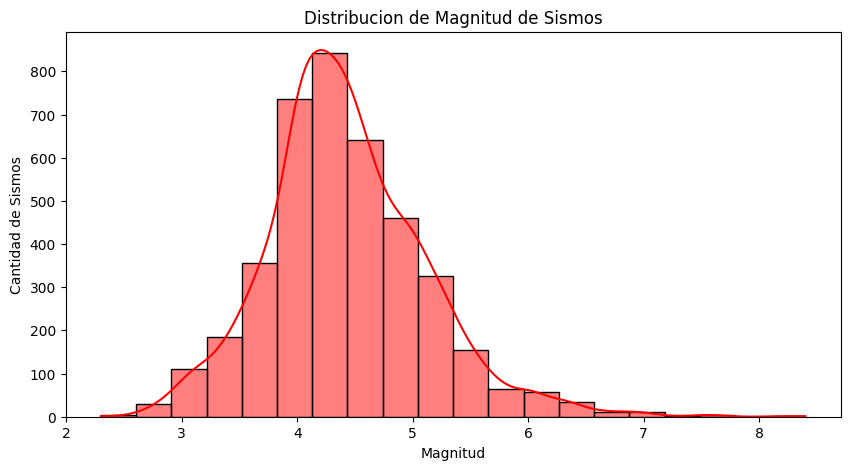

In [ ]:
#EV1 CODIGO 25
#histogrma de magnitud para entender la freciencia de los sismos segun su intensidad
plt.figure(figsize=(10, 5))
sns.histplot(sismos_final['Magnitud'], bins=20, kde=True, color='red')
plt.title('Distribucion de Magnitud de Sismos')
plt.xlabel('Magnitud')
plt.ylabel('Cantidad de Sismos')
plt.show()
#kde es la densidad que suaviza los datos del histograma, nos ayuda
#a poder ver la tendencia general de la distribucion de las magnitudes.

Este grafico de dispersion nos permite evaluar si existe una correlacion entre la intensidad del sismo y su profundidad focal. En este grafico se compara la magnitud del sismo con su profundidad, podemos observar la distribuccion de los puntos, no se puede identificar un patron definido ni una linea de tendencia ya que los puntos se encuentran dispersos, esto nos da la conclusion de que la magnitud de un sismo es independiente de su profundidad.

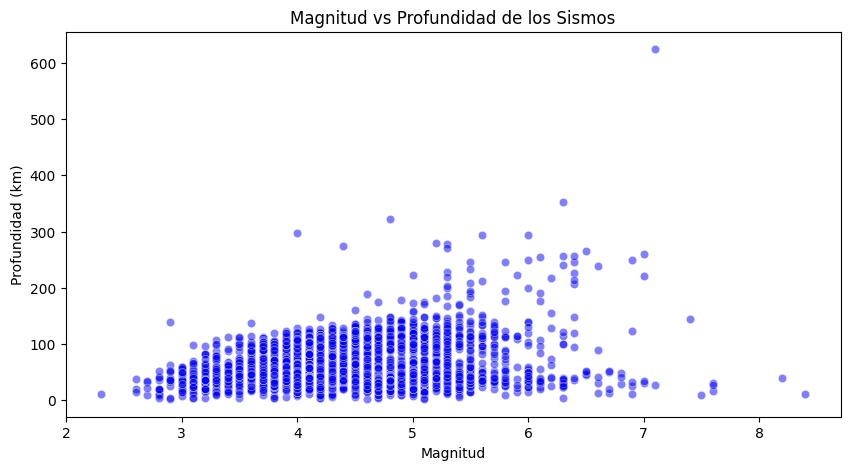

In [ ]:
#EV1 CODIGO 26
#grafico de dispersion para ver si los sismos mas fuertes ocurren a mayor o menor profundidad
plt.figure(figsize=(10, 5))
sns.scatterplot(data=sismos_final, x='Magnitud', y='Profundidad', color='blue', alpha=0.5)
plt.title('Magnitud vs Profundidad de los Sismos')
plt.xlabel('Magnitud')
plt.ylabel('Profundidad (km)')
plt.show()

El grafico boxplot nos muestra que la profundidad de los sismo no son uniforme a lo largo del pais. Las regiones del norte (Arica y Antofagasta) esos eventos presentan una mayor profundidad media,y en otras regiones del sur como Magallanes los sismos son de manera superficial y tambien en el mar se presentan ocasionalmente eventos de gran profundidad.

/tmp/ipykernel_1017/2563522930.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sismos_final, x='Region', y='Profundidad', palette='viridis')


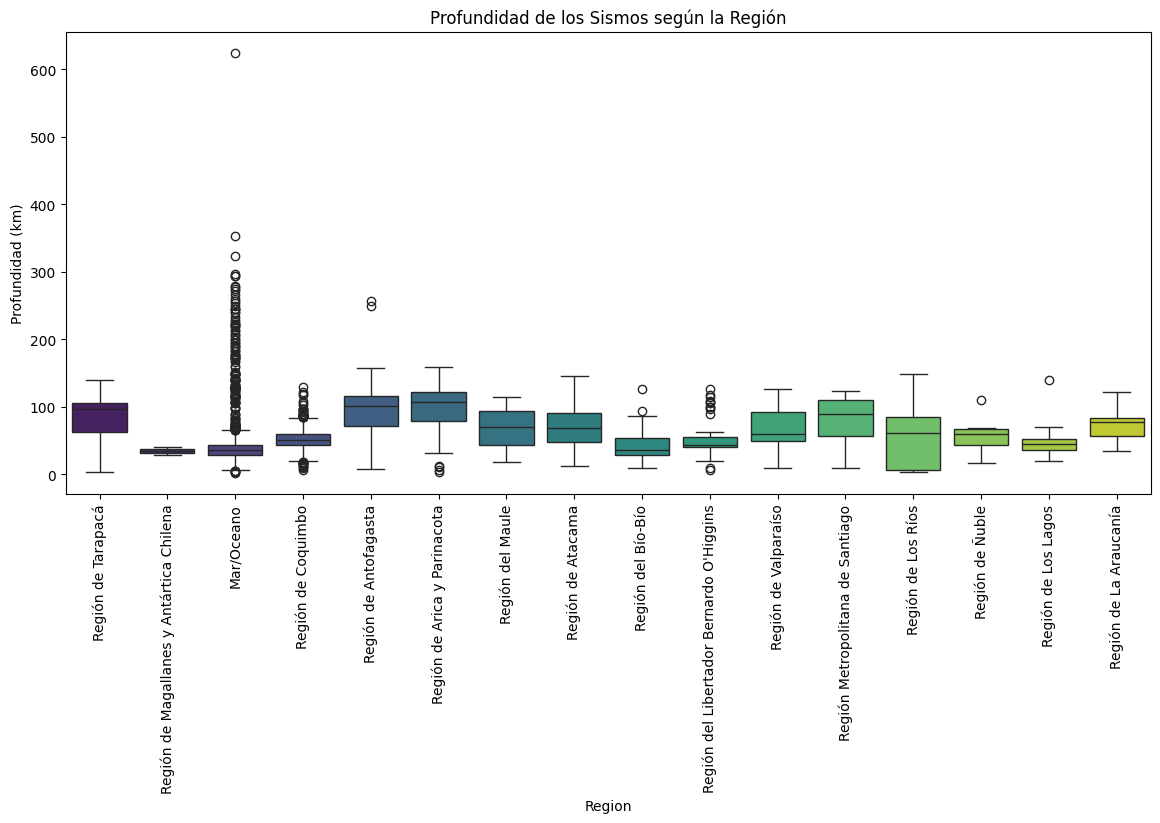

In [ ]:
#EV1 CODIGO 27
#grafico boxplot para comprar varias categorias al mismo tiempo y detectar posibles "outliers"
plt.figure(figsize=(14, 6))
sns.boxplot(data=sismos_final, x='Region', y='Profundidad', palette='viridis')
plt.title('Profundidad de los Sismos según la Región')
plt.xticks(rotation=90) # Rotamos las etiquetas para que se lean bien
plt.ylabel('Profundidad (km)')
plt.show()

# OneHot Encoder y Binary Encoder

In [ ]:
#EV1 CODIGO 28
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.0 MB/s eta 0:00:00


In [ ]:
#EV1 CODIGO 29
#One Hot Encoder para Región usando nombres reales
region_limpia = sismos_final['Region'].astype(str)
#Limpiamos el texto para que las columnas no queden tan largas
region_limpia = region_limpia.str.replace('Región de ', '', regex=False)
region_limpia = region_limpia.str.replace('Región del ', '', regex=False)
region_limpia = region_limpia.str.replace('Región Metropolitana de ', 'Metropolitana de ', regex=False)

#Creamos columnas dummy con nombres reales de regiones
gdf_regiones = pd.get_dummies(region_limpia, prefix='Region', dtype=int)

gdf_regiones.head()

,Region_Antofagasta,Region_Arica y Parinacota,Region_Atacama,Region_Bío-Bío,Region_Coquimbo,Region_La Araucanía,Region_Libertador Bernardo O'Higgins,Region_Los Lagos,Region_Los Ríos,Region_Magallanes y Antártica Chilena,Region_Mar/Oceano,Region_Maule,Region_Metropolitana de Santiago,Region_Tarapacá,Region_Valparaíso,Region_Ñuble
0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [ ]:
#EV1 CODIGO 30
import category_encoders as ce
# Binary Encoder para la columna Comuna
be = ce.BinaryEncoder(cols=['Comuna'])

df_binary = be.fit_transform(sismos_final[['Comuna']])

df_binary.head()

,Comuna_0,Comuna_1,Comuna_2,Comuna_3,Comuna_4,Comuna_5,Comuna_6,Comuna_7
0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,1,1
3,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,1,1


In [ ]:
#EV1 CODIGO 31
#Seleccionamos solo las columnas principales que queremos analizar
df_base = sismos_final[
    ['Fecha', 'Hora', 'Magnitud', 'Latitud', 'Longitud', 'Profundidad']
].copy()

#Concatenamos las variables base + regiones codificadas + comunas codificadas
df_final_encoded = pd.concat([
    df_base.reset_index(drop=True),
    gdf_regiones.reset_index(drop=True),
    df_binary.reset_index(drop=True)
], axis=1)

print(df_final_encoded.head())
print(f"Total de columnas tras el encoder: {len(df_final_encoded.columns)}")

        Fecha      Hora  Magnitud  Latitud  Longitud  Profundidad  \
0  2025-05-26  03:50:27       5.6   -19.63    -69.49           97   
1  2025-05-13  00:47:58       5.1   -51.25    -72.28           28   
2  2025-05-05  09:46:48       5.0   -29.49    -71.84           48   
3  2025-05-05  02:17:48       5.1   -31.89    -70.88           88   
4  2025-05-02  15:23:49       5.8   -27.52    -72.48           30   

   Region_Antofagasta  Region_Arica y Parinacota  Region_Atacama  \
0                   0                          0               0   
1                   0                          0               0   
2                   0                          0               0   
3                   0                          0               0   
4                   0                          0               0   

   Region_Bío-Bío  ...  Region_Valparaíso  Region_Ñuble  Comuna_0  Comuna_1  \
0               0  ...                  0             0         0         0   
1               0 

In [ ]:
#EV1 CODIGO 32
from sklearn.preprocessing import StandardScaler
# Columnas numéricas principales que serán estandarizadas
cols_a_escalar = ['Magnitud', 'Latitud', 'Longitud', 'Profundidad']

scaler = StandardScaler()
# Creamos el dataframe final codificado y escalado
df_final_encoder = df_final_encoded.copy()

# Aplicamos StandardScaler solo a las columnas numéricas principales
df_final_encoder[cols_a_escalar] = scaler.fit_transform(
    df_final_encoder[cols_a_escalar]
)

df_final_encoder.head()

,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Region_Antofagasta,Region_Arica y Parinacota,Region_Atacama,Region_Bío-Bío,...,Region_Valparaíso,Region_Ñuble,Comuna_0,Comuna_1,Comuna_2,Comuna_3,Comuna_4,Comuna_5,Comuna_6,Comuna_7
0,2025-05-26,03:50:27,1.702473,1.377236,1.053335,0.926921,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2025-05-13,00:47:58,0.975838,-3.927232,-1.106204,-0.877499,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,2025-05-05,09:46:48,0.830511,-0.276846,-0.765631,-0.354479,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
3,2025-05-05,02:17:48,0.975838,-0.679462,-0.022564,0.691562,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,2025-05-02,15:23:49,1.993126,0.053635,-1.261009,-0.825197,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1


In [ ]:
#EV1 CODIGO 33
#Matriz de correlación solo con variables numéricas principales
matriz_corr_numericas = df_final_encoder[
    ['Magnitud', 'Latitud', 'Longitud', 'Profundidad']
].corr()

matriz_corr_numericas

,Magnitud,Latitud,Longitud,Profundidad
Magnitud,1.000000,0.088692,0.103796,0.211777
Latitud,0.088692,1.000000,0.727477,0.383838
Longitud,0.103796,0.727477,1.000000,0.668787
Profundidad,0.211777,0.383838,0.668787,1.000000


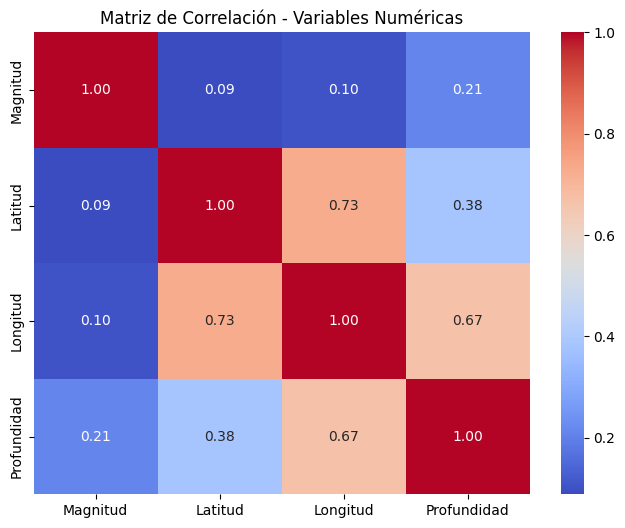

In [ ]:
#EV1 CODIGO 34
plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_corr_numericas,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title('Matriz de Correlación - Variables Numéricas')
plt.show()

In [ ]:
#EV1 CODIGO 35
#Matriz de correlación usando el DataFrame final codificado
df_corr_encoder = df_final_encoder.drop(
    columns=['Fecha', 'Hora'],
    errors='ignore'
)
# Nos quedamos solo con columnas numéricas
df_corr_encoder = df_corr_encoder.select_dtypes(include=['number'])
# Calculamos la matriz de correlación final
matriz_corr_encoder = df_corr_encoder.corr()

matriz_corr_encoder

,Magnitud,Latitud,Longitud,Profundidad,Region_Antofagasta,Region_Arica y Parinacota,Region_Atacama,Region_Bío-Bío,Region_Coquimbo,Region_La Araucanía,...,Region_Valparaíso,Region_Ñuble,Comuna_0,Comuna_1,Comuna_2,Comuna_3,Comuna_4,Comuna_5,Comuna_6,Comuna_7
Magnitud,1.000000,0.088692,0.103796,0.211777,0.130165,0.010524,-0.067939,-0.039854,-0.112613,-0.002168,...,-0.039076,-0.007444,0.008708,-0.028565,-0.009973,-0.059717,-0.092696,-0.046605,0.057796,0.021212
Latitud,0.088692,1.000000,0.727477,0.383838,0.256564,0.218712,-0.008800,-0.154288,-0.237251,-0.097030,...,-0.130722,-0.082635,-0.211473,-0.185654,-0.042353,-0.040983,-0.204839,0.123135,-0.021229,-0.160925
Longitud,0.103796,0.727477,1.000000,0.668787,0.403185,0.128824,0.051556,-0.159955,-0.192487,-0.064593,...,-0.023607,-0.067621,-0.138330,-0.063046,0.125367,0.131700,-0.086756,0.271047,-0.048556,-0.330134
Profundidad,0.211777,0.383838,0.668787,1.000000,0.276034,0.133330,0.058111,-0.046055,-0.128710,0.014784,...,0.026222,-0.009063,0.010726,0.045751,0.161297,0.158572,-0.006651,0.257455,-0.058720,-0.347657
Region_Antofagasta,0.130165,0.256564,0.403185,0.276034,1.000000,-0.044802,-0.076317,-0.030912,-0.162453,-0.016576,...,-0.050020,-0.018024,-0.045377,-0.051337,0.336046,0.327692,0.001821,0.211714,-0.060035,-0.342056
Region_Arica y Parinacota,0.010524,0.218712,0.128824,0.133330,-0.044802,1.000000,-0.034043,-0.013789,-0.072466,-0.007394,...,-0.022312,-0.008040,-0.020241,-0.018470,0.097033,0.030825,0.018532,0.073022,-0.104757,-0.226154
Region_Atacama,-0.067939,-0.008800,0.051556,0.058111,-0.076317,-0.034043,1.000000,-0.023489,-0.123441,-0.012595,...,-0.038008,-0.013696,-0.034480,0.178091,0.088658,0.303347,-0.013272,0.156070,-0.057635,-0.053405
Region_Bío-Bío,-0.039854,-0.154288,-0.159955,-0.046055,-0.030912,-0.013789,-0.023489,1.000000,-0.050000,-0.005102,...,-0.015395,-0.005548,0.132393,0.161965,0.149064,0.052751,0.069859,0.023701,-0.044563,-0.059172
Region_Coquimbo,-0.112613,-0.237251,-0.192487,-0.128710,-0.162453,-0.072466,-0.123441,-0.050000,1.000000,-0.026811,...,-0.080905,-0.029154,-0.073396,-0.042957,-0.070526,0.068868,0.607513,0.253446,-0.391364,-0.049742
Region_La Araucanía,-0.002168,-0.097030,-0.064593,0.014784,-0.016576,-0.007394,-0.012595,-0.005102,-0.026811,1.000000,...,-0.008255,-0.002975,0.297514,0.022333,-0.009383,0.032638,0.041072,0.007816,-0.046537,0.009341


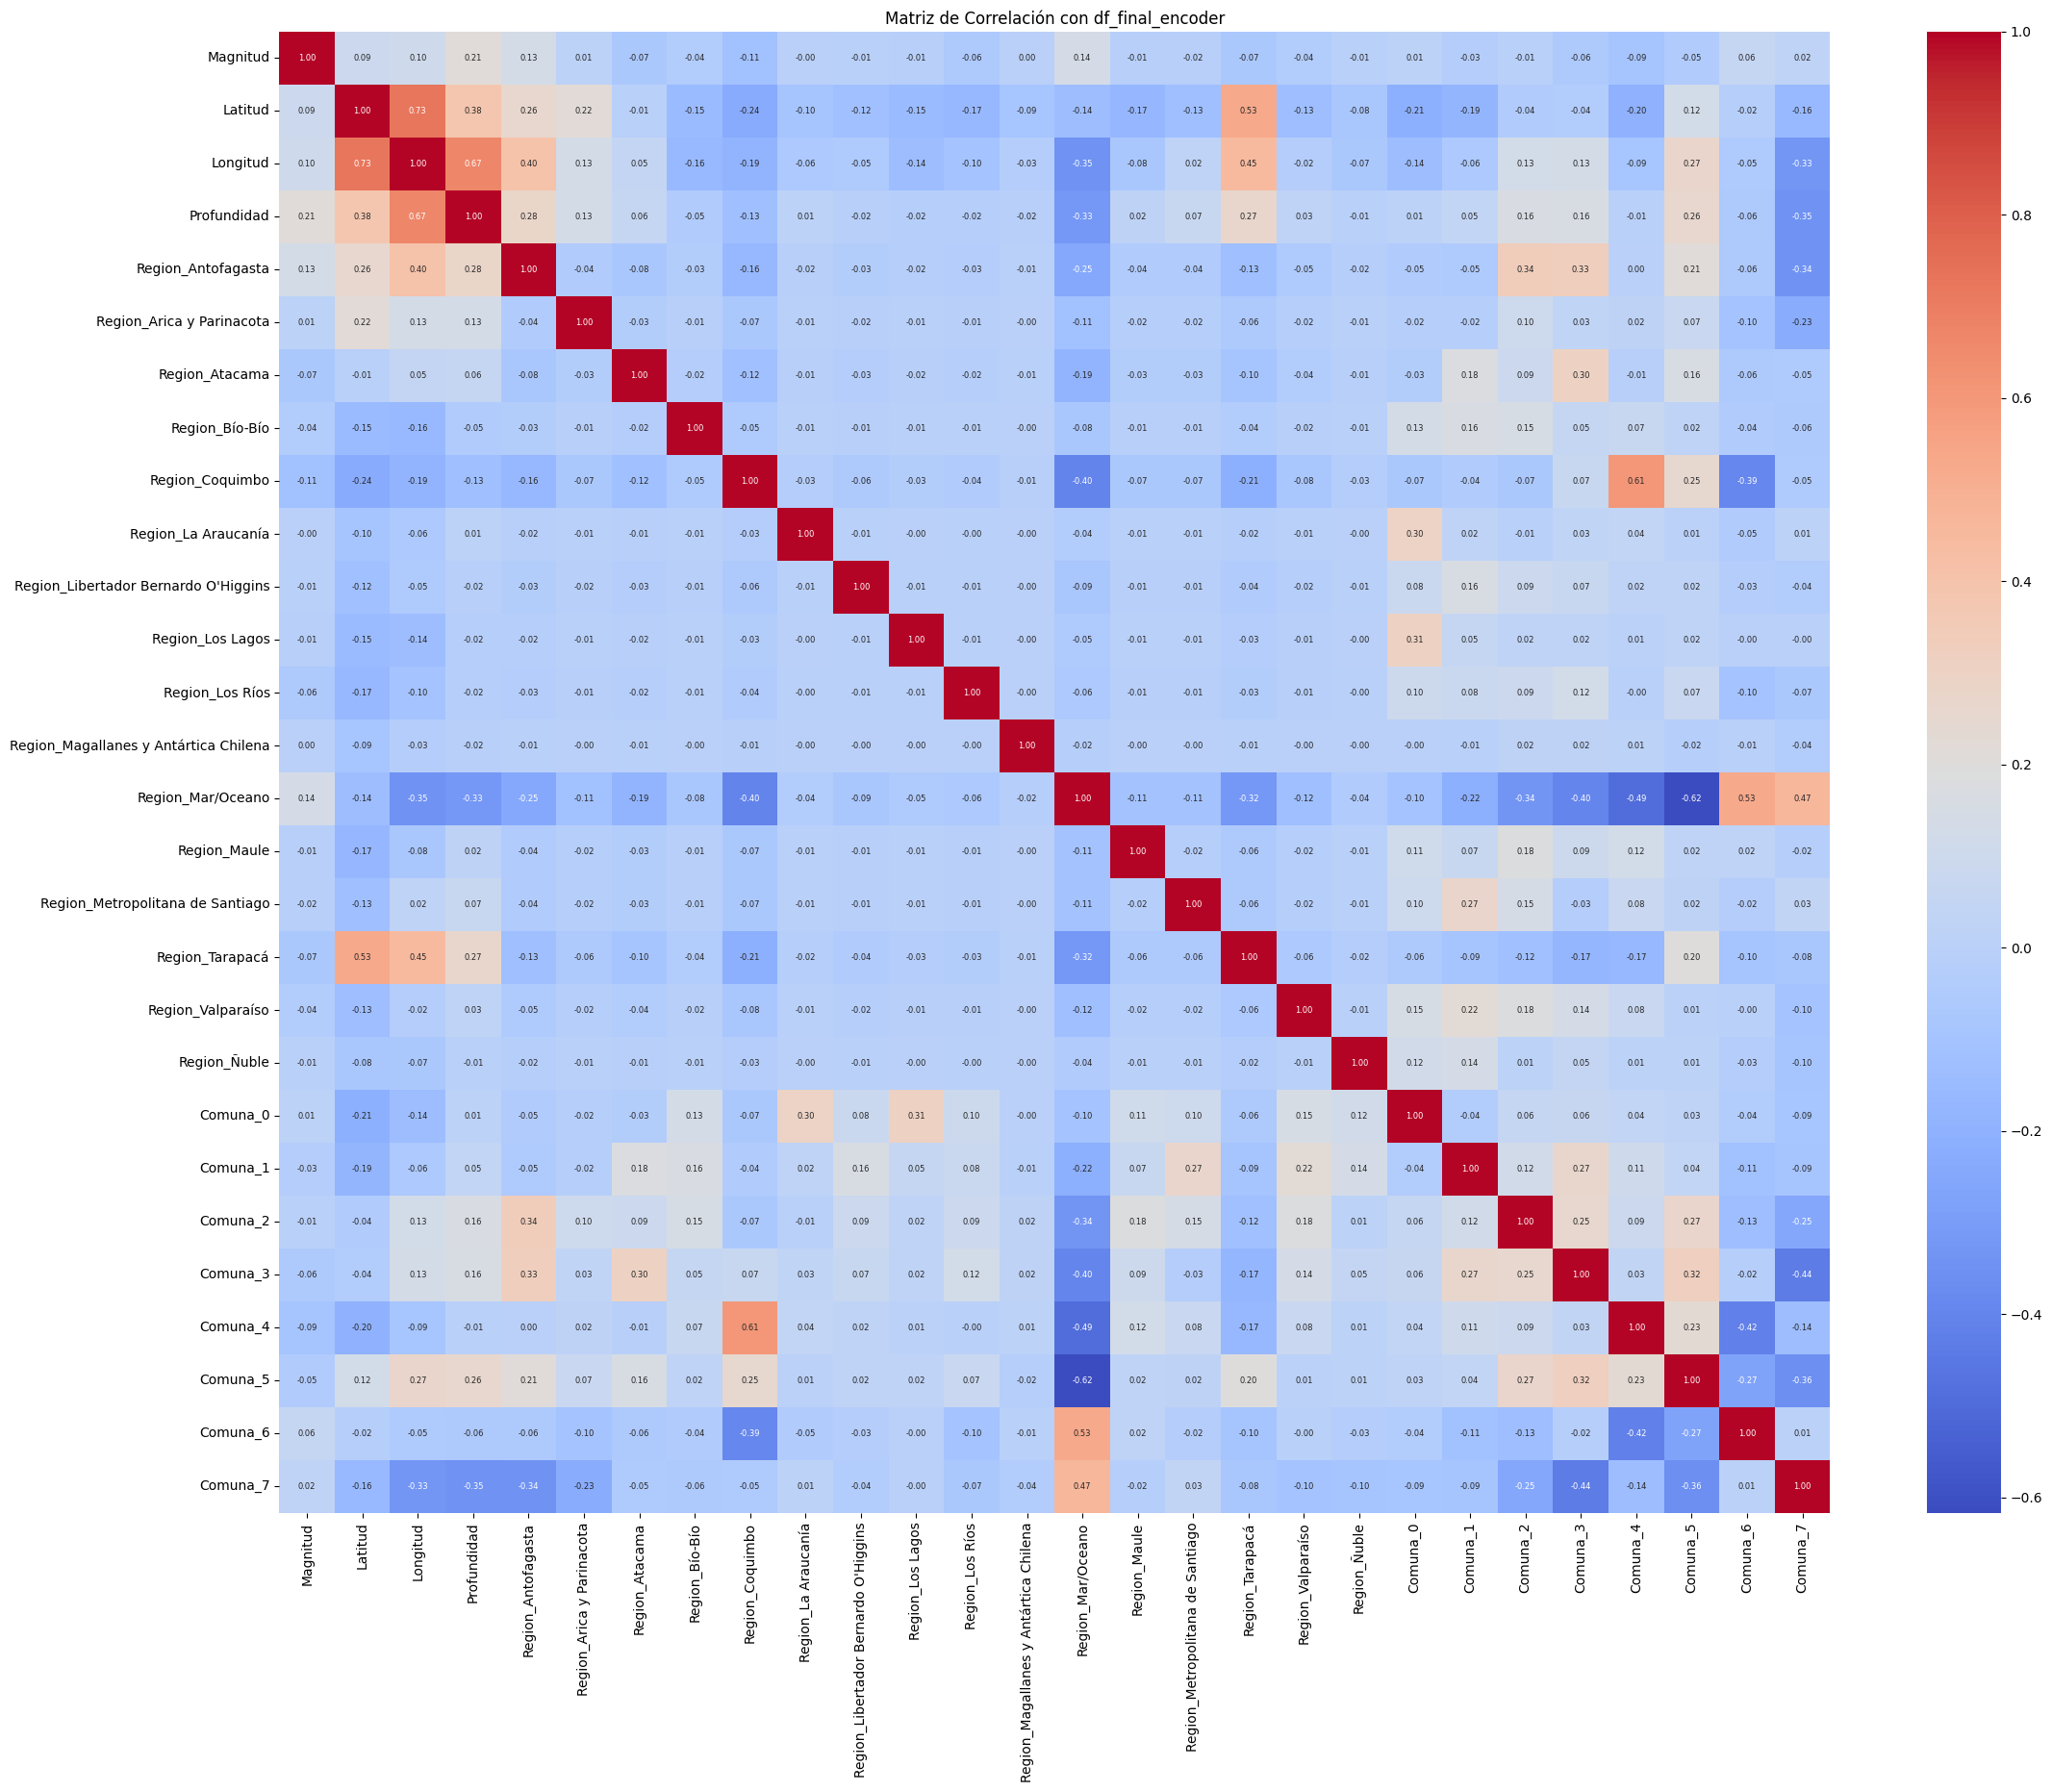

In [ ]:
#EV1 CODIGO 36
plt.figure(figsize=(26, 20))

sns.heatmap(
    matriz_corr_encoder,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    annot_kws={"size": 6}
)

plt.title('Matriz de Correlación con df_final_encoder')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# Informe de Proyecto: Minería de Datos y Modelos Predictivos - Evaluación 2

En esta evaluación se aplica modelación predictiva para analizar si el historial sísmico de las comunas de la Región Metropolitana puede relacionarse con el precio promedio de viviendas.

La hipótesis central del proyecto es:

**Determinar si el historial y magnitud sísmica en la Región Metropolitana impacta directamente en la plusvalía y precio promedio del mercado inmobiliario.**

Para esto, se construye un dataset por comuna, integrando información sísmica y precios promedio de viviendas.

In [ ]:
#EV2 CODIGO 1
#cargamos las librerías para la segunda evaluación
import pandas as pd
import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from matplotlib.ticker import FuncFormatter

In [ ]:
#EV2 CODIGO 2
#carga de datos
sismos_final = pd.read_csv("sismos_final.csv")
mapa_regiones = gpd.read_file("regiones.geojson")
mapa_comunas = gpd.read_file("comunas.geojson")
data_casas = pd.read_csv("data_casas.csv")

print("Sismos:", sismos_final.shape)
print("Casas:", data_casas.shape)

Sismos: (4032, 9)
Casas: (7779, 13)


## Limpieza y normalización de comunas

Como los nombres de comunas pueden venir escritos de forma distinta entre ambos datasets, se normalizan eliminando mayúsculas, espacios y tildes. Esto permite hacer correctamente el cruce entre sismos y precios de viviendas.

In [ ]:
#EV2 CODIGO 3
#limpiamos los nombres de las comunas para que coincidan en ambos
#datasets.
def limpiar_comuna(texto):
    if not isinstance(texto, str):
        return texto

    texto = texto.lower().strip()

    reemplazos = {
        'á': 'a',
        'é': 'e',
        'í': 'i',
        'ó': 'o',
        'ú': 'u',
        'ü': 'u',
        'ñ': 'n'
    }

    for original, limpio in reemplazos.items():
        texto = texto.replace(original, limpio)

    texto = texto.replace(" ", "")

    return texto
# Aplicamos limpieza en ambos datasets
sismos_final['comuna_clean'] = sismos_final['Comuna'].apply(limpiar_comuna)
data_casas['comuna_clean'] = data_casas['Comuna'].apply(limpiar_comuna)

## Ingeniería de características por comuna

Para evitar duplicar precios por cada sismo individual, se agrupan los datos sísmicos por comuna.  
Así, cada comuna queda representada por variables como cantidad de sismos, magnitud promedio, magnitud máxima y profundidad promedio.

In [ ]:
#EV2 CODIGO 4
#calculamos el precio promedio de las viviendas por comuna
#filtramos solo sismos de la Región Metropolitana
sismos_rm = sismos_final[
    sismos_final['Region'].str.contains('Metropolitana', case=False, na=False)
].copy()
# Creamos variables sísmicas agrupadas por comuna
sismos_por_comuna = sismos_rm.groupby('comuna_clean').agg(
    Comuna=('Comuna', 'first'),
    cantidad_sismos=('Magnitud', 'count'),
    magnitud_promedio=('Magnitud', 'mean'),
    magnitud_maxima=('Magnitud', 'max'),
    profundidad_promedio=('Profundidad', 'mean'),
    latitud_promedio=('Latitud', 'mean'),
    longitud_promedio=('Longitud', 'mean')
).reset_index()

sismos_por_comuna.head()

,comuna_clean,Comuna,cantidad_sismos,magnitud_promedio,magnitud_maxima,profundidad_promedio,latitud_promedio,longitud_promedio
0,alhue,Alhué,4,4.175000,4.6,66.750000,-34.082500,-71.160000
1,caleradetango,Calera de Tango,1,5.300000,5.3,92.000000,-33.660000,-70.770000
2,cartagena,Cartagena,1,4.000000,4.0,53.000000,-33.580000,-71.330000
3,colina,Colina,7,4.542857,5.5,86.714286,-33.142857,-70.625714
4,curacavi,Curacaví,1,4.400000,4.4,77.000000,-33.260000,-71.110000


In [ ]:
#EV2 CODIGO 5
#unimos los datos de sismos con los precios promedio de vivienda
#promedio de precio de viviendas por comuna
casas_promedio = data_casas.groupby('comuna_clean').agg(
    precio_usd_promedio=('Price_USD', 'mean')
).reset_index()

# Conversión a pesos chilenos
valor_dolar = 930
casas_promedio['Precio_Casa_Numeric'] = casas_promedio['precio_usd_promedio'] * valor_dolar

casas_promedio.head()

,comuna_clean,precio_usd_promedio,Precio_Casa_Numeric
0,buin,229825.336000,2.137376e+08
1,caleradetango,523451.363636,4.868098e+08
2,cerrillos,189787.531250,1.765024e+08
3,cerronavia,141390.320755,1.314930e+08
4,colina,641445.764919,5.965446e+08


In [ ]:
#EV2 CODIGO 6
#convertimos el precio a pesos chilenos y
# lo dejamos listo para trabajar
#cruce entre historial sísmico y precio promedio de viviendas
dataset_modelo = pd.merge(
    sismos_por_comuna,
    casas_promedio,
    on='comuna_clean',
    how='inner'
)

# Creamos precio formateado solo para visualización
dataset_modelo['Precio_Casa'] = dataset_modelo['Precio_Casa_Numeric'].apply(
    lambda x: f"${x:,.0f}".replace(",", ".")
)

dataset_modelo.head()

,comuna_clean,Comuna,cantidad_sismos,magnitud_promedio,magnitud_maxima,profundidad_promedio,latitud_promedio,longitud_promedio,precio_usd_promedio,Precio_Casa_Numeric,Precio_Casa
0,caleradetango,Calera de Tango,1,5.300000,5.3,92.000000,-33.660000,-70.770000,523451.363636,4.868098e+08,$486.809.768
1,colina,Colina,7,4.542857,5.5,86.714286,-33.142857,-70.625714,641445.764919,5.965446e+08,$596.544.561
2,curacavi,Curacaví,1,4.400000,4.4,77.000000,-33.260000,-71.110000,353145.200000,3.284250e+08,$328.425.036
3,elmonte,El Monte,1,4.800000,4.8,68.000000,-33.680000,-71.100000,112146.529412,1.042963e+08,$104.296.272
4,islademaipo,Isla de Maipo,1,4.000000,4.0,66.000000,-33.740000,-71.020000,298732.608696,2.778213e+08,$277.821.326


## Matriz de correlación

Se aplica una matriz de correlación para revisar la relación entre las variables sísmicas y el precio promedio de vivienda.  
En esta matriz se activan los valores numéricos para facilitar la interpretación de los resultados.

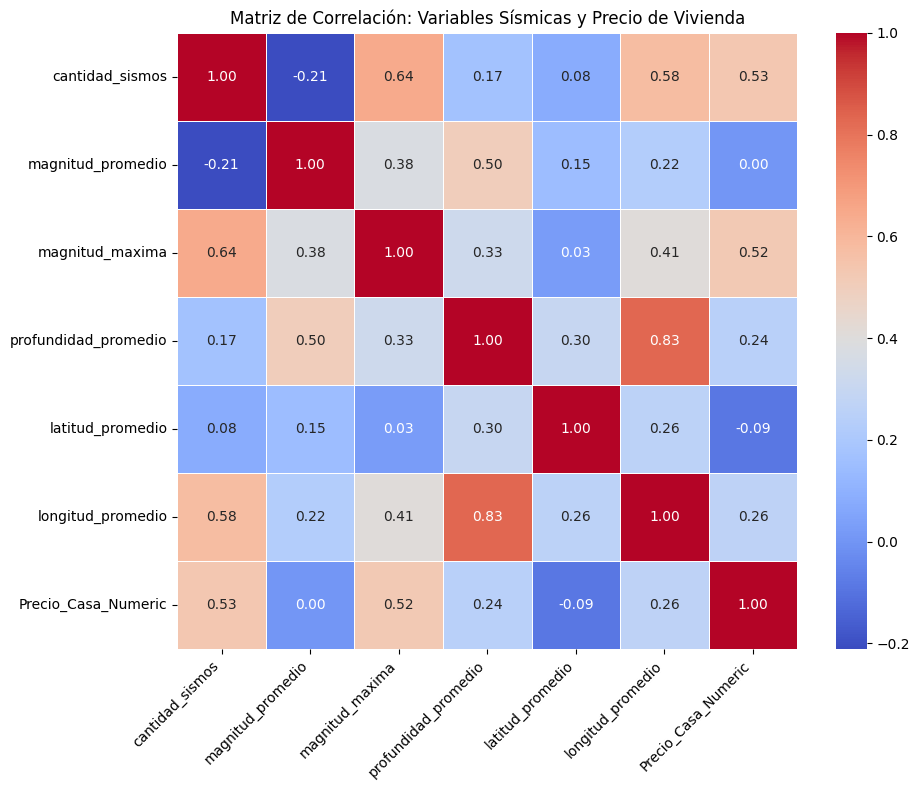

In [ ]:
#EV2 CODIGO 7
#revisamos cómo quedó el nuevo dataset con sismos y viviendas
variables_corr = [
    'cantidad_sismos',
    'magnitud_promedio',
    'magnitud_maxima',
    'profundidad_promedio',
    'latitud_promedio',
    'longitud_promedio',
    'Precio_Casa_Numeric'
]

matriz_corr = dataset_modelo[variables_corr].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title('Matriz de Correlación: Variables Sísmicas y Precio de Vivienda')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

# Informe de Proyecto: Minería de Datos y Modelos Predictivos - Evaluación 2

En esta entrega se aplica un modelo predictivo para analizar la relación entre la magnitud sísmica registrada en la Región Metropolitana y el precio promedio de viviendas por comuna.

La hipótesis central del proyecto es:

**Determinar si el historial y magnitud sísmica en la Región Metropolitana impacta directamente en la plusvalía y precio promedio del mercado inmobiliario.**

In [ ]:
#EV2 CODIGO 8
#definimos la variable de entrada y la variable que queremos predecir
import pandas as pd
import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from matplotlib.ticker import FuncFormatter

In [ ]:
#EV2 CODIGO 9
# Carga de datos
sismos_final = pd.read_csv("sismos_final.csv")
mapa_regiones = gpd.read_file("regiones.geojson")
mapa_comunas = gpd.read_file("comunas.geojson")
data_casas = pd.read_csv("data_casas.csv")

print("Datos de sismos:", sismos_final.shape)
print("Datos de viviendas:", data_casas.shape)

Datos de sismos: (4032, 9)
Datos de viviendas: (7779, 13)


## Limpieza y normalización de comunas

Se normalizan los nombres de las comunas en ambos datasets para poder realizar correctamente el cruce entre los datos sísmicos y los datos de viviendas.

In [ ]:
#EV2 CODIGO 10
def limpiar_comuna(texto):
    if not isinstance(texto, str):
        return texto

    texto = texto.lower().strip()

    reemplazos = {
        'á': 'a',
        'é': 'e',
        'í': 'i',
        'ó': 'o',
        'ú': 'u',
        'ü': 'u',
        'ñ': 'n'
    }

    for original, limpio in reemplazos.items():
        texto = texto.replace(original, limpio)

    texto = texto.replace(" ", "")

    return texto


# Aplicamos limpieza en ambos datasets
sismos_final['comuna_clean'] = sismos_final['Comuna'].apply(limpiar_comuna)
data_casas['comuna_clean'] = data_casas['Comuna'].apply(limpiar_comuna)

# Aseguramos que el precio esté como número
data_casas['Price_USD'] = pd.to_numeric(data_casas['Price_USD'], errors='coerce')

In [ ]:
#EV2 CODIGO 11
# Promedio de precio de viviendas por comuna
casas_promedio = data_casas.groupby('comuna_clean')['Price_USD'].mean().reset_index()

casas_promedio.head()

,comuna_clean,Price_USD
0,buin,229825.336000
1,caleradetango,523451.363636
2,cerrillos,189787.531250
3,cerronavia,141390.320755
4,colina,641445.764919


## Cruce de datos

Se realiza un cruce entre los datos de sismos y el precio promedio de viviendas por comuna.  
Luego, el precio se convierte desde dólares a pesos chilenos para facilitar la interpretación.

In [ ]:
#EV2 CODIGO 12
# Cruce entre sismos y precios promedio de viviendas
sismos_rm_vivienda = pd.merge(
    sismos_final,
    casas_promedio,
    on='comuna_clean',
    how='inner'
)

# Conversión de dólares a pesos chilenos
valor_dolar = 930
sismos_rm_vivienda['Precio_Casa_Numeric'] = (
    sismos_rm_vivienda['Price_USD'] * valor_dolar
).round(0)

# Precio formateado para visualizar
sismos_rm_vivienda['Precio_Casa'] = sismos_rm_vivienda['Precio_Casa_Numeric'].apply(
    lambda x: f"${x:,.0f}".replace(",", ".")
)

# Eliminamos columnas auxiliares que ya no se necesitan
sismos_rm_vivienda = sismos_rm_vivienda.drop(
    columns=['comuna_clean', 'Price_USD'],
    errors='ignore'
)

print("Dataset corregido y limpio:")
sismos_rm_vivienda[['Comuna', 'Magnitud', 'Precio_Casa']].head(21)

Dataset corregido y limpio:


,Comuna,Magnitud,Precio_Casa
0,Talagante,3.9,$377.905.253
1,San José de Maipo,4.7,$579.161.220
2,San Pedro,4.2,$1.236.564.270
3,Padre Hurtado,4.1,$175.331.612
4,Lo Barnechea,4.6,$1.180.599.372
5,Melipilla,4.2,$178.131.229
6,Lo Barnechea,5.6,$1.180.599.372
7,Melipilla,5.5,$178.131.229
8,Curacaví,4.4,$328.425.036
9,Calera de Tango,5.3,$486.809.768


In [ ]:
#EV2 CODIGO 13
sismos_rm_vivienda.head()

,Fecha,Hora,Magnitud,Region,Comuna,Latitud,Longitud,Profundidad,geometry,Precio_Casa_Numeric,Precio_Casa
0,2024-05-05,05:31:52,3.9,Región Metropolitana de Santiago,Talagante,-33.68,-70.82,71,POINT (-70.82 -33.68),3.779053e+08,$377.905.253
1,2024-04-24,09:33:10,4.7,Región Metropolitana de Santiago,San José de Maipo,-33.77,-70.26,116,POINT (-70.26 -33.77),5.791612e+08,$579.161.220
2,2023-09-09,20:03:13,4.2,Región Metropolitana de Santiago,San Pedro,-33.93,-71.30,55,POINT (-71.3 -33.93),1.236564e+09,$1.236.564.270
3,2023-08-24,06:36:58,4.1,Región Metropolitana de Santiago,Padre Hurtado,-33.56,-70.87,80,POINT (-70.87 -33.56),1.753316e+08,$175.331.612
4,2023-08-17,01:42:19,4.6,Región Metropolitana de Santiago,Lo Barnechea,-33.25,-70.40,108,POINT (-70.4 -33.25),1.180599e+09,$1.180.599.372


## Matriz de correlación

Se genera una matriz de correlación para observar la relación entre las variables sísmicas principales y el precio promedio de viviendas.  
En esta matriz se muestran los valores numéricos para facilitar la interpretación.

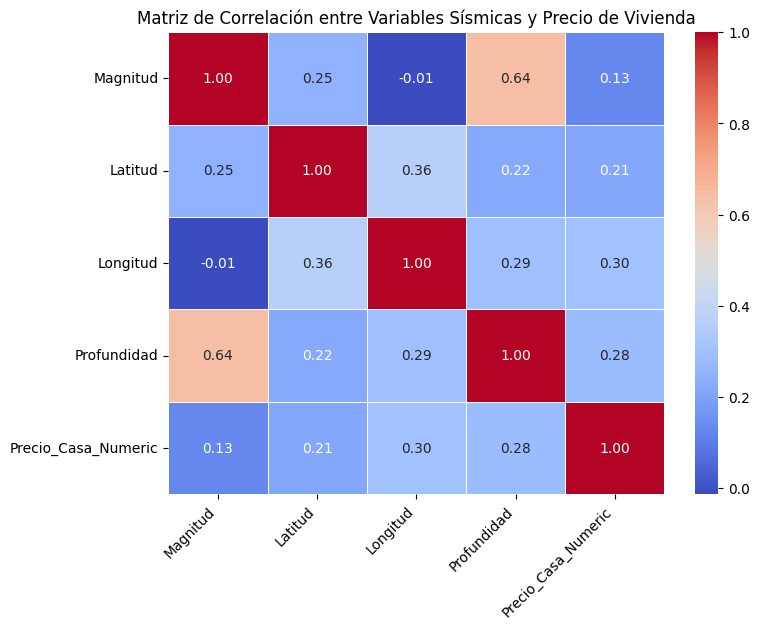

In [ ]:
#EV2 CODIGO 14
# Matriz de correlación con variables numéricas

variables_corr = sismos_rm_vivienda[
    ['Magnitud', 'Latitud', 'Longitud', 'Profundidad', 'Precio_Casa_Numeric']
]

matriz_corr = variables_corr.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title('Matriz de Correlación entre Variables Sísmicas y Precio de Vivienda')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

## Modelo de Predicción: Decision Tree Regressor

Se selecciona el modelo **Decision Tree Regressor** porque la variable objetivo corresponde a un valor numérico continuo: el precio promedio de vivienda.

El modelo utiliza la magnitud del sismo como variable independiente y el precio promedio de vivienda como variable dependiente.

In [ ]:
#EV2 CODIGO 15
# Variable independiente
X = sismos_rm_vivienda[['Magnitud']]

# Variable dependiente
y = sismos_rm_vivienda['Precio_Casa_Numeric']

print("Variable independiente X:")
print(X.head())

print("\nVariable dependiente y:")
print(y.head())

Variable independiente X:
   Magnitud
0       3.9
1       4.7
2       4.2
3       4.1
4       4.6

Variable dependiente y:
0    3.779053e+08
1    5.791612e+08
2    1.236564e+09
3    1.753316e+08
4    1.180599e+09
Name: Precio_Casa_Numeric, dtype: float64


In [ ]:
#EV2 CODIGO 16
# Inicializamos el modelo Decision Tree Regressor
modelo_dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=4
)

# Entrenamos el modelo
modelo_dt.fit(X, y)

# Realizamos predicciones
y_pred_dt = modelo_dt.predict(X)

## Evaluación del modelo

Se calculan métricas para evaluar el rendimiento del modelo.  
El R² permite observar qué proporción de la variación del precio puede ser explicada por la magnitud del sismo.

In [ ]:
#EV2 CODIGO 17
# Métricas de evaluación
mse_dt = mean_squared_error(y, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y, y_pred_dt)
mae_dt = mean_absolute_error(y, y_pred_dt)

print("Resultados Decision Tree Regressor")
print("-----------------------------------")
print(f"Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse_dt:,.0f}".replace(",", "."))
print(f"R-squared (R2): {r2_dt:.2f}")
print(f"Mean Absolute Error (MAE): ${mae_dt:,.0f}".replace(",", "."))

Resultados Decision Tree Regressor
-----------------------------------
Mean Squared Error (MSE): 111118615109728752.00
Root Mean Squared Error (RMSE): $333.344.589
R-squared (R2): 0.19
Mean Absolute Error (MAE): $269.986.222


## Visualización de predicciones

Se grafican los datos reales y la predicción del modelo Decision Tree Regressor.  
La línea escalonada representa cómo el árbol de decisión divide los valores de magnitud para estimar el precio promedio de vivienda.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


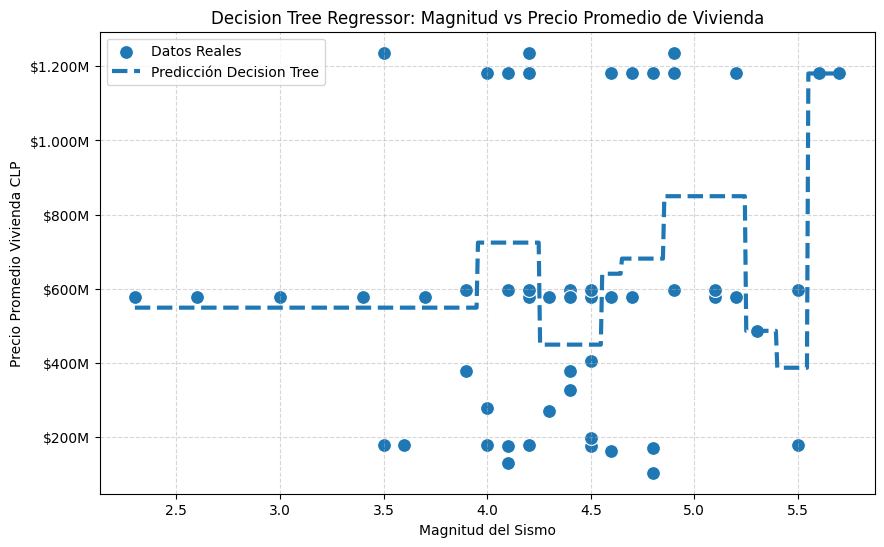

In [ ]:
#EV2 CODIGO 18
plt.figure(figsize=(10, 6))

# Datos reales
sns.scatterplot(
    data=sismos_rm_vivienda,
    x='Magnitud',
    y='Precio_Casa_Numeric',
    s=100,
    label='Datos Reales'
)

# Línea ordenada para visualizar la predicción del árbol
X_linea = np.linspace(X['Magnitud'].min(), X['Magnitud'].max(), 500).reshape(-1, 1)
y_linea_pred = modelo_dt.predict(X_linea)

plt.plot(
    X_linea,
    y_linea_pred,
    linewidth=3,
    linestyle='--',
    label='Predicción Decision Tree'
)

plt.title('Decision Tree Regressor: Magnitud vs Precio Promedio de Vivienda')
plt.xlabel('Magnitud del Sismo')
plt.ylabel('Precio Promedio Vivienda CLP')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f"${x/1e6:,.0f}M".replace(",", "."))
)

plt.show()

## Visualización del árbol de decisión

Se grafica el árbol de decisión para observar las reglas utilizadas por el modelo.  
En el árbol se muestran los valores de corte, la cantidad de muestras y el valor promedio estimado en cada nodo.

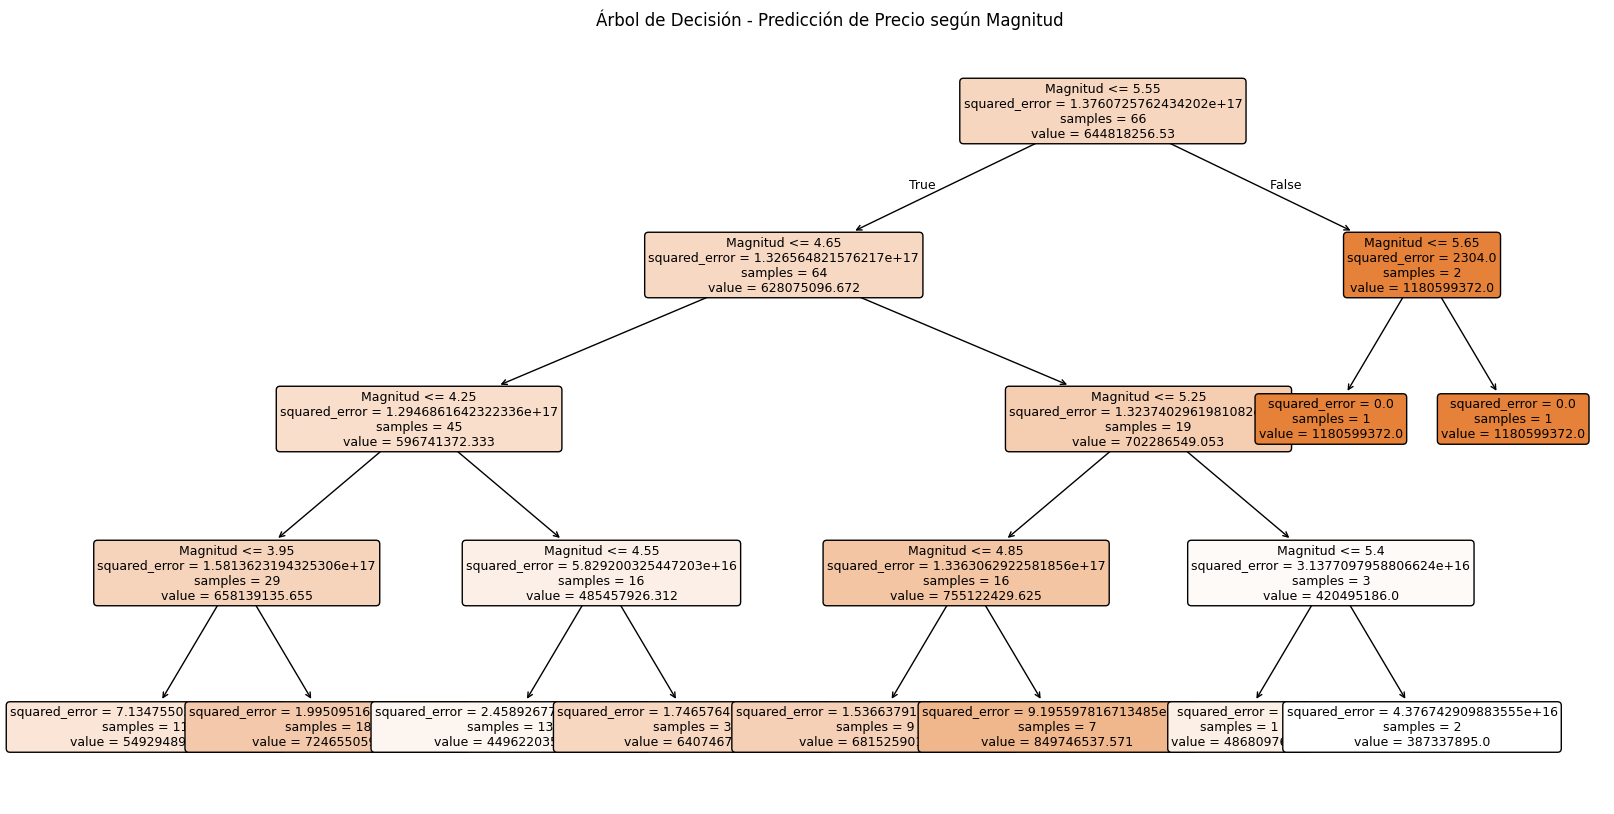

In [ ]:
#EV2 CODIGO 19
plt.figure(figsize=(20, 10))

plot_tree(
    modelo_dt,
    feature_names=['Magnitud'],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title('Árbol de Decisión - Predicción de Precio según Magnitud')
plt.show()

## Análisis de resultados

El modelo Decision Tree Regressor permitió analizar la relación entre la magnitud sísmica y el precio promedio de viviendas.  
La matriz de correlación permitió visualizar numéricamente la relación entre magnitud, latitud, longitud, profundidad y precio de vivienda.

Los resultados muestran que la magnitud sísmica puede tener cierta relación con el precio promedio, pero no permite explicar completamente la variación del mercado inmobiliario. Esto se debe a que el precio de una vivienda también depende de otros factores como ubicación, conectividad, seguridad, servicios cercanos, nivel socioeconómico y plusvalía histórica de la comuna.

Por lo tanto, la hipótesis se puede analizar de forma parcial: la magnitud sísmica puede aportar información al análisis, pero no es suficiente por sí sola para afirmar que impacta directamente en la plusvalía o precio promedio de las viviendas.

# Evaluación 3: Integración Final, K-Means, Métricas, Dashboard y Web Scraping

En esta sección se incorporan los requisitos de la tercera evaluación.  
Se mantiene el trabajo corregido de la Evaluación 1 y Evaluación 2, y se agregan nuevos elementos para complementar el análisis:

- Set de datos de prueba.
- Métricas específicas de evaluación del modelo.
- Modelo K-Means.
- Dataset final para dashboard en Google Looker Studio o Power BI.
- Web scraping como bonus para obtener datos reales recientes.

In [ ]:
# EV3 CODIGO 1
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Set de datos de prueba

Para evaluar el rendimiento del modelo de forma más realista, se divide el dataset en datos de entrenamiento y datos de prueba.  
El modelo aprende con una parte de los datos y luego se evalúa con datos que no fueron utilizados durante el entrenamiento.

In [ ]:
# EV3 CODIGO 2
#Verificamos que exista la columna numérica para que el modelo pueda calcular,
#pero en pantalla mostraremos el precio con formato normal.
if 'Precio_Casa_Numeric' not in sismos_rm_vivienda.columns:
    sismos_rm_vivienda['Precio_Casa_Numeric'] = (
        sismos_rm_vivienda['Precio_Casa']
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace('.', '', regex=False)
        .astype(float)
    )

#Dejamos Precio_Casa con formato bonito para mostrar
sismos_rm_vivienda['Precio_Casa'] = sismos_rm_vivienda['Precio_Casa_Numeric'].apply(
    lambda x: f"${x:,.0f}".replace(",", ".")
)

#Mostramos solo el precio bonito, no el numérico
sismos_rm_vivienda[['Comuna', 'Magnitud', 'Precio_Casa']].head()

,Comuna,Magnitud,Precio_Casa
0,Talagante,3.9,$377.905.253
1,San José de Maipo,4.7,$579.161.220
2,San Pedro,4.2,$1.236.564.270
3,Padre Hurtado,4.1,$175.331.612
4,Lo Barnechea,4.6,$1.180.599.372


In [ ]:
# EV3 CODIGO 3
#variable independiente
X_ev3 = sismos_rm_vivienda[['Magnitud']]

#variable dependiente
y_ev3 = sismos_rm_vivienda['Precio_Casa_Numeric']

#separación en entrenamiento y prueba
X_train_ev3, X_test_ev3, y_train_ev3, y_test_ev3 = train_test_split(
    X_ev3,
    y_ev3,
    test_size=0.30,
    random_state=42
)

print("Datos de entrenamiento:", X_train_ev3.shape)
print("Datos de prueba:", X_test_ev3.shape)

Datos de entrenamiento: (46, 1)
Datos de prueba: (20, 1)


## Métricas específicas de evaluación del modelo

Se evalúa el modelo de regresión utilizando métricas como MSE, RMSE, MAE y R².  
Estas métricas permiten medir el error del modelo y analizar qué tan bien la magnitud sísmica permite explicar el precio promedio de las viviendas.

In [ ]:
# EV3 CODIGO 4
from sklearn.tree import DecisionTreeRegressor

modelo_dt_ev3 = DecisionTreeRegressor(
    random_state=42,
    max_depth=4
)

#entrenamos con los datos de entrenamiento
modelo_dt_ev3.fit(X_train_ev3, y_train_ev3)

#predecimos con los datos de prueba
y_pred_ev3 = modelo_dt_ev3.predict(X_test_ev3)

In [ ]:
# EV3 CODIGO 5
mse_ev3 = mean_squared_error(y_test_ev3, y_pred_ev3)
rmse_ev3 = np.sqrt(mse_ev3)
mae_ev3 = mean_absolute_error(y_test_ev3, y_pred_ev3)
r2_ev3 = r2_score(y_test_ev3, y_pred_ev3)

print("Métricas del modelo Decision Tree Regressor")
print("------------------------------------------")
print(f"MSE: {mse_ev3:.2f}")
print(f"RMSE: ${rmse_ev3:,.0f}".replace(",", "."))
print(f"MAE: ${mae_ev3:,.0f}".replace(",", "."))
print(f"R2: {r2_ev3:.2f}")

Métricas del modelo Decision Tree Regressor
------------------------------------------
MSE: 229980131132163072.00
RMSE: $479.562.437
MAE: $390.825.506
R2: -1.68


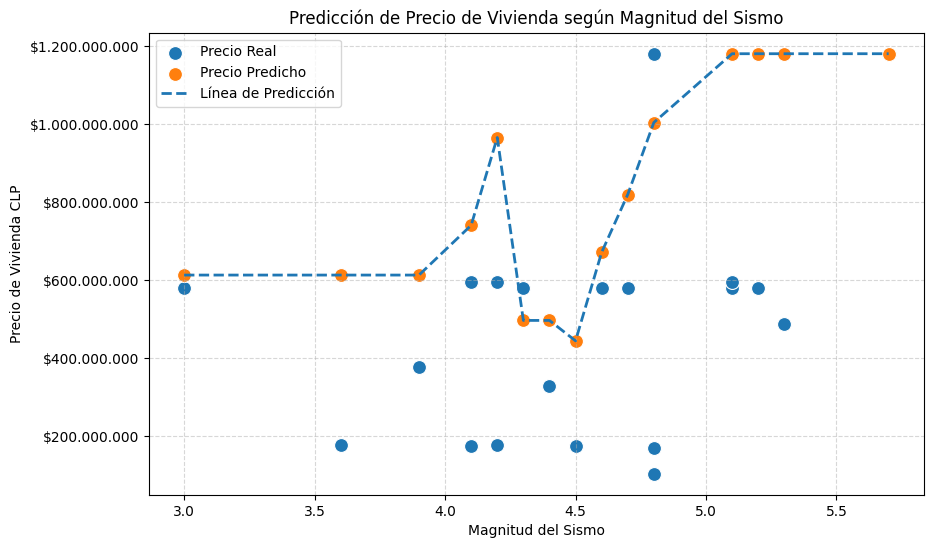

In [ ]:
# EV3 CODIGO 6
from matplotlib.ticker import FuncFormatter
#creamos dataframe con magnitud, precio real y precio predicho
resultados_ev3 = pd.DataFrame({
    'Magnitud': X_test_ev3['Magnitud'],
    'Precio_Real': y_test_ev3,
    'Precio_Predicho': y_pred_ev3
})

#ordenamos por magnitud para que la línea de predicción se vea clara
resultados_ev3 = resultados_ev3.sort_values(by='Magnitud')

plt.figure(figsize=(10, 6))

#puntos reales
sns.scatterplot(
    data=resultados_ev3,
    x='Magnitud',
    y='Precio_Real',
    s=100,
    label='Precio Real'
)

#puntos predichos
sns.scatterplot(
    data=resultados_ev3,
    x='Magnitud',
    y='Precio_Predicho',
    s=100,
    label='Precio Predicho'
)

#línea de predicción
plt.plot(
    resultados_ev3['Magnitud'],
    resultados_ev3['Precio_Predicho'],
    linestyle='--',
    linewidth=2,
    label='Línea de Predicción'
)

plt.title('Predicción de Precio de Vivienda según Magnitud del Sismo')
plt.xlabel('Magnitud del Sismo')
plt.ylabel('Precio de Vivienda CLP')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

#formato de pesos chilenos
formato_pesos = FuncFormatter(lambda x, p: f"${x:,.0f}".replace(",", "."))

ax = plt.gca()
ax.yaxis.set_major_formatter(formato_pesos)
ax.yaxis.get_offset_text().set_visible(False)

plt.show()

## Modelo K-Means

K-Means es un modelo de aprendizaje no supervisado que permite agrupar registros según similitudes matemáticas entre sus variables.

A diferencia del modelo de regresión, K-Means no predice un precio, sino que identifica grupos de sismos con características parecidas. Para este análisis se utilizan las variables Magnitud, Latitud, Longitud y Profundidad.

Siguiendo el material de reforzamiento, primero se evalúa el número de clusters mediante el método del codo y el coeficiente de Silhouette. Luego se aplica K-Means y se interpretan los grupos encontrados.

In [ ]:
#EV3 CODIGO 7
#Evaluación del número de clusters para K-Means
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

#seleccionamos variables para K-Means
variables_kmeans = sismos_rm_vivienda[
    ['Magnitud', 'Latitud', 'Longitud', 'Profundidad']
].copy()

#escalamos las variables para que todas tengan una escala comparable
scaler_kmeans = StandardScaler()
variables_kmeans_scaled = scaler_kmeans.fit_transform(variables_kmeans)

#evaluamos distintos valores de k
sse = []
silhouette_scores = []

rango_k = range(2, 8)

for k in rango_k:
    kmeans_eval = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=42
    )

    kmeans_eval.fit(variables_kmeans_scaled)

    sse.append(kmeans_eval.inertia_)
    silhouette_scores.append(
        silhouette_score(variables_kmeans_scaled, kmeans_eval.labels_)
    )

# Mostramos resultados en tabla
evaluacion_kmeans = pd.DataFrame({
    'Cantidad_Clusters': list(rango_k),
    'Inercia_SSE': sse,
    'Silhouette_Score': silhouette_scores
})

evaluacion_kmeans

,Cantidad_Clusters,Inercia_SSE,Silhouette_Score
0,2,171.161261,0.368340
1,3,115.575912,0.405643
2,4,86.882516,0.343121
3,5,70.568688,0.355262
4,6,60.187668,0.341765
5,7,51.477400,0.333843


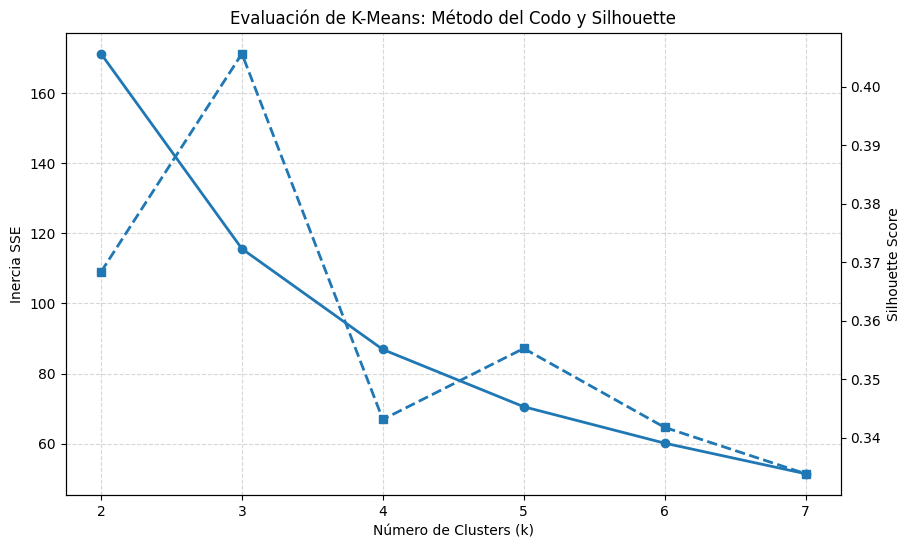

In [ ]:
# EV3 CODIGO 8
#Gráfico del método del codo y Silhouette

fig, ax1 = plt.subplots(figsize=(10, 6))

#Método del codo
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia SSE')
ax1.plot(rango_k, sse, marker='o', linewidth=2, label='Inercia SSE')
ax1.grid(True, linestyle='--', alpha=0.5)

#Silhouette
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score')
ax2.plot(rango_k, silhouette_scores, marker='s', linewidth=2, linestyle='--', label='Silhouette Score')

plt.title('Evaluación de K-Means: Método del Codo y Silhouette')
plt.show()

Según el método del codo y el coeficiente de Silhouette, se decide trabajar con 3 clusters. Esta cantidad permite separar los sismos en grupos interpretables según magnitud, profundidad y ubicación geográfica.

In [ ]:
# EV3 CODIGO 9
#aplicación final de K-Means
k_optimo = 3

kmeans = KMeans(
    n_clusters=k_optimo,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

#asignamos el cluster a cada registro
sismos_rm_vivienda['Cluster_KMeans'] = kmeans.fit_predict(variables_kmeans_scaled)

sismos_rm_vivienda[['Comuna', 'Magnitud', 'Profundidad', 'Cluster_KMeans']].head()

,Comuna,Magnitud,Profundidad,Cluster_KMeans
0,Talagante,3.9,71,0
1,San José de Maipo,4.7,116,1
2,San Pedro,4.2,55,0
3,Padre Hurtado,4.1,80,0
4,Lo Barnechea,4.6,108,1


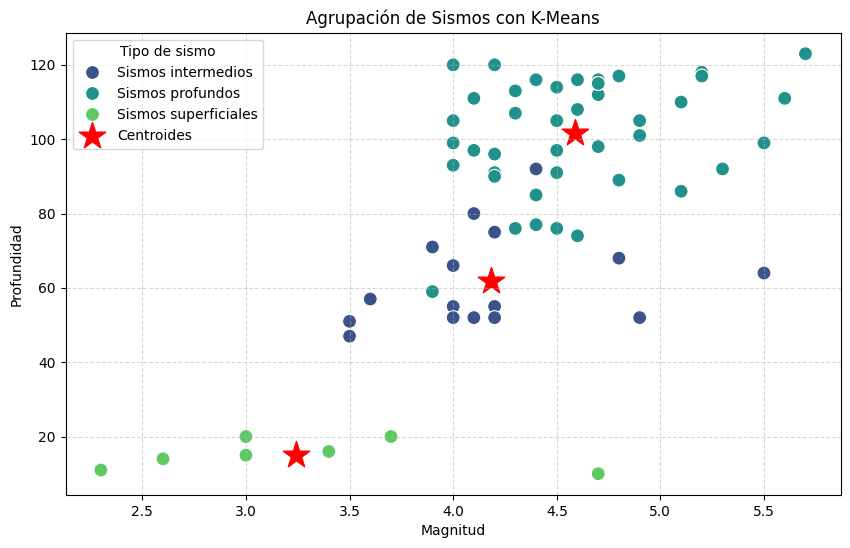

In [ ]:
# EV3 CODIGO 10
# visualización de k-means con centroides y nombres más claros para cada cluster

# convertimos los centroides escalados a la escala original
centroides_originales = scaler_kmeans.inverse_transform(kmeans.cluster_centers_)

centroides_df = pd.DataFrame(
    centroides_originales,
    columns=['Magnitud', 'Latitud', 'Longitud', 'Profundidad']
)

# ordenamos los clusters según la profundidad promedio
orden_clusters = centroides_df['Profundidad'].sort_values().index.tolist()

# les ponemos un nombre más entendible
nombres_clusters = {
    orden_clusters[0]: 'Sismos superficiales',
    orden_clusters[1]: 'Sismos intermedios',
    orden_clusters[2]: 'Sismos profundos'
}

# creamos una nueva columna con el nombre del cluster
sismos_rm_vivienda['Tipo_Cluster'] = sismos_rm_vivienda['Cluster_KMeans'].map(nombres_clusters)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sismos_rm_vivienda,
    x='Magnitud',
    y='Profundidad',
    hue='Tipo_Cluster',
    palette='viridis',
    s=100
)

# agregamos centroides
plt.scatter(
    centroides_df['Magnitud'],
    centroides_df['Profundidad'],
    marker='*',
    s=400,
    color='red',
    label='Centroides'
)

plt.title('Agrupación de Sismos con K-Means')
plt.xlabel('Magnitud')
plt.ylabel('Profundidad')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Tipo de sismo')
plt.show()

In [ ]:
#EV3 CODIGO 11
#Resumen de clusters
resumen_clusters = sismos_rm_vivienda.groupby('Cluster_KMeans').agg(
    cantidad_sismos=('Magnitud', 'count'),
    magnitud_promedio=('Magnitud', 'mean'),
    magnitud_maxima=('Magnitud', 'max'),
    profundidad_promedio=('Profundidad', 'mean'),
    precio_promedio=('Precio_Casa_Numeric', 'mean')
).round(2).reset_index()

# Creamos precio con formato visual
resumen_clusters['precio_promedio_visual'] = resumen_clusters['precio_promedio'].apply(
    lambda x: f"${x:,.0f}".replace(",", ".")
)

# Mostramos tabla ordenada y entendible
resumen_clusters_mostrar = resumen_clusters[[
    'Cluster_KMeans',
    'cantidad_sismos',
    'magnitud_promedio',
    'magnitud_maxima',
    'profundidad_promedio',
    'precio_promedio_visual'
]]

resumen_clusters_mostrar

,Cluster_KMeans,cantidad_sismos,magnitud_promedio,magnitud_maxima,profundidad_promedio,precio_promedio_visual
0,0,16,4.18,5.5,61.81,$466.248.610
1,1,43,4.59,5.7,101.70,$721.951.131
2,2,7,3.24,4.7,15.14,$579.161.220


## Interpretación de resultados K-Means

El modelo K-Means agrupó los sismos en tres clusters según sus características sísmicas.

Cada cluster representa un grupo de eventos con comportamiento similar en magnitud, profundidad y ubicación geográfica. El resumen permite comparar la cantidad de sismos, magnitud promedio, magnitud máxima, profundidad promedio y precio promedio de vivienda asociado a cada grupo.

Este análisis no busca predecir el precio de vivienda, sino complementar el modelo predictivo mediante agrupaciones que apoyen la toma de decisiones y permitan detectar patrones dentro de los registros sísmicos.

Dataset para Looker / Power BI (kristyn)

https://datastudio.google.com/reporting/02ace0a6-a552-4787-bb94-75dd0863c8ab

In [ ]:
sismos_rm_vivienda['Fecha'] = sismos_rm_vivienda['Fecha'].astype(str)
sismos_rm_vivienda.to_csv('sismos_kmeans_dashboard.csv', index=False)
print("Dataset 'sismos_kmeans_dashboard.csv' creado con éxito. Puedes importarlo en Google Sheets.")

Dataset 'sismos_kmeans_dashboard.csv' creado con éxito. Puedes importarlo en Google Sheets.


## BONUS: Web Scraping con datos reales recientes

Como complemento del proyecto, se realiza web scraping desde la página oficial del Centro Sismológico Nacional para obtener datos recientes de sismos en Chile.

Estos datos no reemplazan al dataset principal, ya que no contienen todas las columnas necesarias para el cruce con viviendas, como comuna exacta, región, latitud, longitud o precio de vivienda.

Sin embargo, se utilizan como datos reales externos para testear el modelo predictivo, usando la magnitud obtenida desde la web para generar nuevas predicciones de precio estimado.

In [ ]:
# EV3 CODIGO BONUS 1
#Web Scraping desde la página del Centro Sismológico Nacional
url_sismologia = "https://www.sismologia.cl/index.html"

tablas = pd.read_html(url_sismologia)

print(f"Tablas encontradas: {len(tablas)}")

sismos_web = tablas[0]

sismos_web.head()

Tablas encontradas: 1


,Fecha Local / Lugar (2),ProfundidadProf.,MagnitudMag.
0,2026-07-01 13:14:43 67 km al SE de Socaire,201 km,3.3
1,2026-07-01 11:22:45 30 km al O de Ollagüe,132 km,2.5
2,2026-07-01 10:59:53 49 km al SO de San Pedro ...,99 km,2.9
3,2026-07-01 09:02:48 57 km al SE de Camiña,99 km,2.8
4,2026-07-01 08:25:23 20 km al E de Curicó,83 km,2.9


In [ ]:
# EV3 CODIGO BONUS 2
#Limpieza del dataset obtenido por web scraping
sismos_web_limpio = sismos_web.copy()

sismos_web_limpio = sismos_web_limpio.rename(columns={
    'Fecha Local / Lugar (2)': 'Fecha_Lugar',
    'ProfundidadProf.': 'Profundidad',
    'MagnitudMag.': 'Magnitud'
})

#extraemos fecha, hora y lugar
sismos_web_limpio['Fecha'] = sismos_web_limpio['Fecha_Lugar'].astype(str).str.slice(0, 10)
sismos_web_limpio['Hora'] = sismos_web_limpio['Fecha_Lugar'].astype(str).str.slice(11, 19)
sismos_web_limpio['Lugar'] = sismos_web_limpio['Fecha_Lugar'].astype(str).str.slice(20)

#limpiamos profundidad
sismos_web_limpio['Profundidad'] = (
    sismos_web_limpio['Profundidad']
    .astype(str)
    .str.replace('km', '', regex=False)
    .str.strip()
    .astype(float)
)

#convertimos magnitud a número
sismos_web_limpio['Magnitud'] = pd.to_numeric(
    sismos_web_limpio['Magnitud'],
    errors='coerce'
)

sismos_web_limpio = sismos_web_limpio[
    ['Fecha', 'Hora', 'Lugar', 'Magnitud', 'Profundidad']
]

sismos_web_limpio = sismos_web_limpio.dropna(
    subset=['Magnitud', 'Profundidad']
)

sismos_web_limpio.head()

,Fecha,Hora,Lugar,Magnitud,Profundidad
0,2026-07-01,13:14:43,67 km al SE de Socaire,3.3,201.0
1,2026-07-01,11:22:45,30 km al O de Ollagüe,2.5,132.0
2,2026-07-01,10:59:53,49 km al SO de San Pedro de Atacama,2.9,99.0
3,2026-07-01,09:02:48,57 km al SE de Camiña,2.8,99.0
4,2026-07-01,08:25:23,20 km al E de Curicó,2.9,83.0


## Testeo con datos reales obtenidos por Web Scraping

Para no modificar el modelo K-Means principal del proyecto, se construye un segundo modelo K-Means compatible con los datos obtenidos desde la página de Sismología.

El scraping entrega principalmente magnitud y profundidad, por lo que este modelo bonus utiliza solo esas variables.  
De esta forma, los nuevos sismos reales obtenidos desde la web pueden ser clasificados en clusters.

In [ ]:
# EV3 CODIGO BONUS 3
#K-Means auxiliar para testear datos reales del web scraping
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#usamos solo las variables que también existen en el scraping
variables_kmeans_bonus = sismos_rm_vivienda[
    ['Magnitud', 'Profundidad']
].copy()

#escalamos las variables
scaler_kmeans_bonus = StandardScaler()
variables_kmeans_bonus_scaled = scaler_kmeans_bonus.fit_transform(variables_kmeans_bonus)

#creamos un segundo K-Means solo para el bonus
kmeans_bonus = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
#entrenamos el K-Means auxiliar
sismos_rm_vivienda['Cluster_KMeans_Bonus'] = kmeans_bonus.fit_predict(
    variables_kmeans_bonus_scaled
)

sismos_rm_vivienda[['Comuna', 'Magnitud', 'Profundidad', 'Cluster_KMeans_Bonus']].head()

,Comuna,Magnitud,Profundidad,Cluster_KMeans_Bonus
0,Talagante,3.9,71,1
1,San José de Maipo,4.7,116,2
2,San Pedro,4.2,55,1
3,Padre Hurtado,4.1,80,1
4,Lo Barnechea,4.6,108,2


In [ ]:
# EV3 CODIGO BONUS 4
#Testeo de modelos con datos reales obtenidos por web scraping
sismos_web_testeo = sismos_web_limpio.copy()

#Testeo del Decision Tree con la magnitud del scraping
X_web = sismos_web_testeo[['Magnitud']]

sismos_web_testeo['Precio_Predicho_Numeric'] = modelo_dt_ev3.predict(X_web)

sismos_web_testeo['Precio_Predicho'] = sismos_web_testeo['Precio_Predicho_Numeric'].apply(
    lambda x: f"${x:,.0f}".replace(",", ".")
)

#Testeo del K-Means auxiliar con magnitud y profundidad
variables_web_bonus = sismos_web_testeo[
    ['Magnitud', 'Profundidad']
].copy()

variables_web_bonus_scaled = scaler_kmeans_bonus.transform(variables_web_bonus)

sismos_web_testeo['Cluster_KMeans_Bonus'] = kmeans_bonus.predict(
    variables_web_bonus_scaled
)

sismos_web_testeo[
    ['Fecha', 'Hora', 'Lugar', 'Magnitud', 'Profundidad', 'Precio_Predicho', 'Cluster_KMeans_Bonus']
].head(10)

,Fecha,Hora,Lugar,Magnitud,Profundidad,Precio_Predicho,Cluster_KMeans_Bonus
0,2026-07-01,13:14:43,67 km al SE de Socaire,3.3,201.0,$613.380.770,2
1,2026-07-01,11:22:45,30 km al O de Ollagüe,2.5,132.0,$613.380.770,1
2,2026-07-01,10:59:53,49 km al SO de San Pedro de Atacama,2.9,99.0,$613.380.770,1
3,2026-07-01,09:02:48,57 km al SE de Camiña,2.8,99.0,$613.380.770,1
4,2026-07-01,08:25:23,20 km al E de Curicó,2.9,83.0,$613.380.770,0
5,2026-07-01,08:01:05,15 km al O de Pozo Almonte,2.5,64.0,$613.380.770,0
6,2026-07-01,07:32:16,44 km al NO de Concepción,2.8,14.0,$613.380.770,0
7,2026-07-01,07:06:08,23 km al N de Mina Los Pelambres,3.1,103.0,$613.380.770,1
8,2026-07-01,06:24:51,18 km al SO de Visviri,3.3,154.0,$613.380.770,2
9,2026-07-01,05:58:52,68 km al E de Socaire,3.1,234.0,$613.380.770,2


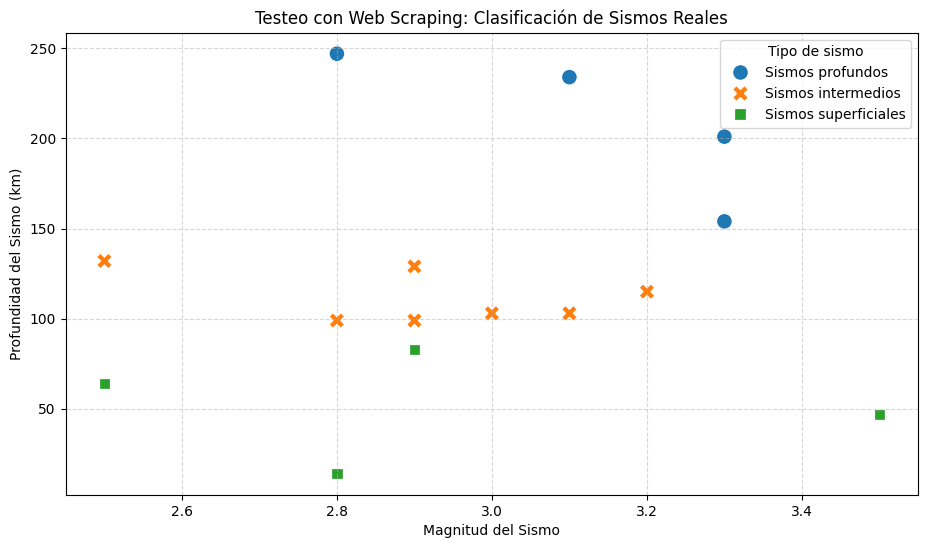

In [ ]:
# EV3 CODIGO BONUS 5
# Gráfico de clasificación de sismos reales obtenidos por web scraping
# Primero interpretamos los clusters según su profundidad promedio
orden_clusters = (
    sismos_web_testeo
    .groupby('Cluster_KMeans_Bonus')['Profundidad']
    .mean()
    .sort_values()
    .index
    .tolist()
)

nombres_clusters = {
    orden_clusters[0]: 'Sismos superficiales',
    orden_clusters[1]: 'Sismos intermedios',
    orden_clusters[2]: 'Sismos profundos'
}

sismos_web_testeo['Tipo_Cluster'] = sismos_web_testeo['Cluster_KMeans_Bonus'].map(nombres_clusters)

# Gráfico más claro
plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=sismos_web_testeo,
    x='Magnitud',
    y='Profundidad',
    hue='Tipo_Cluster',
    style='Tipo_Cluster',
    s=130
)

plt.title('Testeo con Web Scraping: Clasificación de Sismos Reales')
plt.xlabel('Magnitud del Sismo')
plt.ylabel('Profundidad del Sismo (km)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Tipo de sismo')

plt.show()

In [ ]:
# EV3 CODIGO BONUS 6
# Resumen del testeo con datos web
resumen_web_clusters = sismos_web_testeo.groupby('Tipo_Cluster').agg(
    cantidad_sismos=('Magnitud', 'count'),
    magnitud_promedio=('Magnitud', 'mean'),
    magnitud_maxima=('Magnitud', 'max'),
    profundidad_promedio=('Profundidad', 'mean'),
    precio_predicho_promedio=('Precio_Predicho_Numeric', 'mean')
).round(2).reset_index()

resumen_web_clusters['precio_predicho_promedio'] = resumen_web_clusters['precio_predicho_promedio'].apply(
    lambda x: f"${x:,.0f}".replace(",", ".")
)

resumen_web_clusters

,Tipo_Cluster,cantidad_sismos,magnitud_promedio,magnitud_maxima,profundidad_promedio,precio_predicho_promedio
0,Sismos intermedios,7,2.91,3.2,111.43,$613.380.770
1,Sismos profundos,4,3.12,3.3,209.00,$613.380.770
2,Sismos superficiales,4,2.92,3.5,52.00,$613.380.770


In [ ]:
# EV3 CODIGO BONUS 7
# Guardamos el dataset web testeado con los modelos
sismos_web_testeo.to_csv("sismos_web_testeo_modelos.csv", index=False)

print("Archivo sismos_web_testeo_modelos.csv creado correctamente.")

sismos_web_testeo[
    ['Fecha', 'Hora', 'Lugar', 'Magnitud', 'Profundidad', 'Precio_Predicho', 'Tipo_Cluster']
].head()

Archivo sismos_web_testeo_modelos.csv creado correctamente.


,Fecha,Hora,Lugar,Magnitud,Profundidad,Precio_Predicho,Tipo_Cluster
0,2026-07-01,13:14:43,67 km al SE de Socaire,3.3,201.0,$613.380.770,Sismos profundos
1,2026-07-01,11:22:45,30 km al O de Ollagüe,2.5,132.0,$613.380.770,Sismos intermedios
2,2026-07-01,10:59:53,49 km al SO de San Pedro de Atacama,2.9,99.0,$613.380.770,Sismos intermedios
3,2026-07-01,09:02:48,57 km al SE de Camiña,2.8,99.0,$613.380.770,Sismos intermedios
4,2026-07-01,08:25:23,20 km al E de Curicó,2.9,83.0,$613.380.770,Sismos superficiales


El gráfico permite visualizar cómo los sismos reales obtenidos mediante web scraping fueron clasificados por el modelo K-Means auxiliar.  
Para facilitar la interpretación, los clusters fueron renombrados según su profundidad promedio: sismos superficiales, intermedios y profundos.  
Esto permite observar que los datos externos pueden ser incorporados al análisis y clasificados automáticamente según sus características sísmicas.